In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import random
import networkx as nx
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
import importlib
import shap
import requests
import io
import sys
import re
import openai
import groq
import nltk


from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.model_selection import train_test_split
from datetime import datetime
from lingam import VARLiNGAM
from matplotlib import gridspec
from IPython.display import display, Markdown, HTML
from matplotlib.ticker import FormatStrFormatter
from typing import Dict, Any, List, Literal, Optional, Tuple
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_score, KFold
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from bert_score import score
from dotenv import load_dotenv
from selenium import webdriver
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.metrics import make_scorer
from pathlib import Path
from sklearn.model_selection import train_test_split
from pprint import pprint
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler
from nltk.stem import PorterStemmer
from sklearn.metrics.pairwise import cosine_similarity


# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

<br> <br>

####  Helper function to determine output folder based on persona

In [2]:
# Helper function to determine output folder based on persona
def get_output_folder_for_persona(persona: str, base_path: str = "llm_response") -> str:
    """
    Generate output folder path based on persona
    
    Args:
        persona: Either "data_scientist" or "operator"
        base_path: Base path for LLM responses
        
    Returns:
        Complete path with persona-specific subfolder
    """
    if persona == "data_scientist":
        return f"{base_path}/data_scientist"
    elif persona == "operator":
        return f"{base_path}/machine_operator"
    else:
        # Default fallback
        return f"{base_path}/{persona}"

print("✅ Helper function for persona-based paths loaded")

✅ Helper function for persona-based paths loaded


<br> <br> <br>

## Load dataset, feature engineering and pre-processing

In [3]:
# Load the AI4I 2020 dataset
print("📊 Loading AI4I 2020 Dataset for Causality Analysis")
print("=" * 60)


def feature_engineering(df):

    # scaler = StandardScaler()
    # label_encoder = LabelEncoder()
    minmax_scaler = MinMaxScaler()
    encoder = OrdinalEncoder(categories=[["L", "M", "H"]])

    df.rename(
        columns={
            "Air temperature [K]": "Air_temperature",
            "Process temperature [K]": "Process_temperature",
            "Rotational speed [rpm]": "Rotational_speed",
            "Torque [Nm]": "Torque",
            "Tool wear [min]": "Tool_wear",
            "Failure Type": "Failure_Type",
        },
        inplace=True,
    )

    # Engineered Features
    df["Power_output"] = df["Torque"] * df["Rotational_speed"]
    df["wear_torque_product"] = df["Tool_wear"] * df["Torque"]
    df["Temp_difference"] = np.abs(df["Air_temperature"] - df["Process_temperature"])

    # exclude_columns = ["Type", "Failure Type"]
    mapping = {"L": 1, "M": 2, "H": 3}
    df["Type_n"] = df["Type"].map(mapping)
    df["Type_n"] = encoder.fit_transform(df[["Type"]]).astype(int)

    exclude_columns = ["Failure_Type", "Target", "Type_n"]

    df.drop(columns=["Product ID", "UDI", "Type"], inplace=True)

    # Columns to scale
    columns_to_scale = [col for col in df.columns if col not in exclude_columns]

    df_minmax = df.copy()
    df_minmax[columns_to_scale] = minmax_scaler.fit_transform(
        df_minmax[columns_to_scale]
    )
    df_minmax = pd.concat(
        [df_minmax[columns_to_scale], df_minmax[exclude_columns]], axis=1
    )

    return df_minmax


# Load the predictive maintenance dataset
# df_pm = pd.read_csv(os.path.join(paths['data_path'], 'ai4i_2020', 'predictive_maintenance.csv'))
df_pm = pd.read_csv("../../data/ai4i_2020/predictive_maintenance.csv")


# Count rows before filtering
rows_before = len(df_pm)

# Remove rows where Target is 1 and Failure_Type is "No Failure" --> (Noise)
df_pm = df_pm[~((df_pm['Target'] == 1) & (df_pm['Failure Type'] == "No Failure"))]

# Count rows after filtering
rows_after = len(df_pm)
print(f"📝 Removed {rows_before - rows_after} noise rows (Target=1 & Failure_Type='No Failure')")

# Apply feature engineering
df_processed = feature_engineering(df_pm)

# Remove Random Failures (as discussed in previous analysis)
df_processed = df_processed[df_processed['Failure_Type'] != 'Random Failures']

print(f"📊 Dataset shape after preprocessing: {df_processed.shape}")
print(f"🎯 Target distribution: {df_processed['Target'].value_counts().to_dict()}")
print(f"📋 Available features: {list(df_processed.columns)}")

📊 Loading AI4I 2020 Dataset for Causality Analysis
📝 Removed 9 noise rows (Target=1 & Failure_Type='No Failure')
📊 Dataset shape after preprocessing: (9973, 11)
🎯 Target distribution: {0: 9643, 1: 330}
📋 Available features: ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Power_output', 'wear_torque_product', 'Temp_difference', 'Failure_Type', 'Target', 'Type_n']


In [4]:
df_processed.head()

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
0,0.304348,0.358025,0.222934,0.535714,0.000000,0.622557,0.000000,0.644444,No Failure,0,1
1,0.315217,0.370370,0.139697,0.583791,0.011858,0.609161,0.008420,0.644444,No Failure,0,0
2,0.304348,0.345679,0.192084,0.626374,0.019763,0.708143,0.014972,0.622222,No Failure,0,0
3,0.315217,0.358025,0.154249,0.490385,0.027668,0.512694,0.016761,0.622222,No Failure,0,0
4,0.315217,0.370370,0.139697,0.497253,0.035573,0.509509,0.021822,0.644444,No Failure,0,0


In [5]:

# Drop columns not used for features
X = df_processed.drop(columns=["Target", "Failure_Type"])
y = df_processed["Target"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train shape: (7978, 9)
X_test shape: (1995, 9)
y_train distribution:
0    7714
1     264
Name: Target, dtype: int64
y_test distribution:
0    1929
1      66
Name: Target, dtype: int64


<br> <br> <br>

## Causality


In [6]:
# Prepare features for causality analysis
print("🔧 Preparing Features for Causality Analysis")
print("=" * 60)

# Define the key features to analyze for causality
# These are the core predictive maintenance features from AI4I 2020 dataset
features_for_causality = [
    'Air_temperature',
    'Process_temperature', 
    'Rotational_speed',
    'Torque',
    'Tool_wear',
    'Power_output',
    'wear_torque_product',
    'Temp_difference',
    'Type_n',  # Machine type
    'Target'   # Include Target to analyze relationships with features
]

# Validate all features exist in the dataset
available_features = [f for f in features_for_causality if f in df_processed.columns]
missing_features = [f for f in features_for_causality if f not in df_processed.columns]

if missing_features:
    print(f"⚠️  Features not found in dataset: {missing_features}")
    features_for_causality = available_features

print(f"✅ Features selected for causality analysis ({len(features_for_causality)}):")
for i, feature in enumerate(features_for_causality, 1):
    print(f"   {i}. {feature}")

print(f"\n📊 Feature matrix shape: {df_processed[features_for_causality].shape}")
print(f"🎯 Target variable included in causality analysis")

🔧 Preparing Features for Causality Analysis
✅ Features selected for causality analysis (10):
   1. Air_temperature
   2. Process_temperature
   3. Rotational_speed
   4. Torque
   5. Tool_wear
   6. Power_output
   7. wear_torque_product
   8. Temp_difference
   9. Type_n
   10. Target

📊 Feature matrix shape: (9973, 10)
🎯 Target variable included in causality analysis


In [7]:
def create_causality_ai4i_2020(df: pd.DataFrame, features_to_analyze: List[str], save_path: str, regularize: bool = True, 
                               noise_level: float = 1e-4, include_target: bool = True,) -> Tuple[List[Dict], plt.Figure]:
    """
    Create causality analysis using VARLiNGAM for the AI4I 2020 dataset.

    Args:
        df: DataFrame containing the processed AI4I 2020 dataset
        features_to_analyze: List of feature names to include in causality analysis
        save_path: Path to save the causality graph JSON file
        regularize: Whether to apply regularization if LinAlgError occurs
        noise_level: Standard deviation of noise to add during regularization
        include_target: Whether to include the Target variable in the analysis

    Returns:
        Tuple containing:
        - List of dictionaries representing causal relationships
        - Matplotlib figure object of the causal network graph
    """
    print("🔍 Starting Causality Analysis for AI4I 2020 Dataset")
    print("=" * 60)

    # Prepare feature list
    analysis_features = features_to_analyze.copy()
    if include_target and "Target" not in analysis_features:
        analysis_features.append("Target")

    # Validate features exist in dataframe
    missing_features = [f for f in analysis_features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Features not found in dataframe: {missing_features}")

    print(f"📊 Features to analyze: {len(analysis_features)}")
    print(f"   {analysis_features}")

    # Extract data for analysis
    X_causal = df[analysis_features].values
    print(f"📈 Data shape for causality analysis: {X_causal.shape}")

    # Initialize the VARLiNGAM model
    print("\n🤖 Initializing VARLiNGAM model...")
    model = VARLiNGAM()

    # Attempt to fit the model with error handling
    try:
        print("🔄 Fitting VARLiNGAM model...")
        model.fit(X_causal)
        print("✅ Model fitted successfully!")

    except np.linalg.LinAlgError as e:
        print(f"⚠️  LinAlgError encountered: {e}")

        if regularize:
            print(f"🔧 Applying regularization with noise level: {noise_level}")
            # Add small amount of noise to handle singularity issues
            X_causal_regularized = X_causal + np.random.normal(
                0, noise_level, X_causal.shape
            )
            model.fit(X_causal_regularized)
            print("✅ Model fitted successfully with regularization!")
        else:
            print("❌ Regularization disabled. Raising error.")
            raise e

    # Retrieve the adjacency matrices
    adjacency_matrices = model.adjacency_matrices_
    print(f"📊 Number of adjacency matrices (lags): {len(adjacency_matrices)}")

    # Build causal relationships
    print("\n🔗 Building causal relationships...")
    G = nx.DiGraph()
    G.add_nodes_from(analysis_features)
    n_features = len(analysis_features)
    causal_relationships = []

    # Process each adjacency matrix (one per lag)
    total_edges = 0
    for lag_index, adj_matrix in enumerate(adjacency_matrices):
        lag_edges = 0

        for i in range(n_features):
            for j in range(n_features):
                weight = adj_matrix[i, j]

                if abs(weight) > 1e-6:  # Filter out very small weights
                    source_feature = analysis_features[i]
                    target_feature = analysis_features[j]

                    # Create edge dictionary
                    edge_dict = {
                        "source_feature": source_feature,
                        "target_feature": target_feature,
                        "effect_strength": float(weight),
                        "lag": lag_index,
                    }

                    causal_relationships.append(edge_dict)
                    G.add_edge(
                        source_feature, target_feature, weight=weight, lag=lag_index
                    )
                    lag_edges += 1

        if lag_edges > 0:
            print(f"   Lag {lag_index}: {lag_edges} causal relationships found")
        total_edges += lag_edges

    print(f"📈 Total causal relationships found: {total_edges}")

    # Create visualization
    print("\n🎨 Creating causality visualization...")
    fig, ax = plt.subplots(figsize=(14, 10))

    if total_edges > 0:
        # Use spring layout for better visualization
        pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42)

        # Separate Target node visually if included
        if include_target and "Target" in analysis_features:
            # Color nodes differently
            node_colors = [
                "#FF6B6B" if node == "Target" else "#4ECDC4" for node in G.nodes()
            ]
            node_sizes = [2000 if node == "Target" else 1500 for node in G.nodes()]
        else:
            node_colors = ["#4ECDC4"] * len(G.nodes())
            node_sizes = [1500] * len(G.nodes())

        # Draw nodes
        nx.draw_networkx_nodes(
            G,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            alpha=0.8,
            edgecolors="black",
            linewidths=2,
            ax=ax,
        )

        # Draw edges with different colors for positive/negative effects
        edges = G.edges(data=True)
        positive_edges = [(u, v) for u, v, d in edges if d["weight"] > 0]
        negative_edges = [(u, v) for u, v, d in edges if d["weight"] < 0]

        # Draw positive edges (green)
        if positive_edges:
            pos_weights = [abs(G[u][v]["weight"]) * 3 for u, v in positive_edges]
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=positive_edges,
                width=pos_weights,
                edge_color="#27AE60",
                arrowsize=20,
                arrowstyle="->",
                alpha=0.7,
                ax=ax,
            )

        # Draw negative edges (red)
        if negative_edges:
            neg_weights = [abs(G[u][v]["weight"]) * 3 for u, v in negative_edges]
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=negative_edges,
                width=neg_weights,
                edge_color="#E74C3C",
                arrowsize=20,
                arrowstyle="->",
                alpha=0.7,
                ax=ax,
            )

        # Draw labels
        nx.draw_networkx_labels(
            G, pos, font_size=10, font_weight="bold", font_color="white", ax=ax
        )

        # Draw edge labels for significant relationships
        edge_labels = {}
        for u, v, d in G.edges(data=True):
            if abs(d["weight"]) > 0.1:  # Only show labels for stronger relationships
                edge_labels[(u, v)] = f"{d['weight']:.2f}"

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=8,
            font_color="black",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
            ax=ax,
        )

    else:
        # No causal relationships found
        ax.text(
            0.5,
            0.5,
            "No significant causal relationships found",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
        )

    # Set title and styling
    ax.set_title(
        "Causal Network Graph for AI4I 2020 Dataset\n(VARLiNGAM Analysis)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.axis("off")

    # Add legend
    if total_edges > 0:
        legend_elements = [
            plt.Line2D(
                [0], [0], color="#27AE60", linewidth=3, label="Positive Causal Effect"
            ),
            plt.Line2D(
                [0], [0], color="#E74C3C", linewidth=3, label="Negative Causal Effect"
            ),
        ]
        if include_target:
            legend_elements.extend(
                [
                    plt.Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="#FF6B6B",
                        markersize=12,
                        label="Target Variable",
                    ),
                    plt.Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="#4ECDC4",
                        markersize=12,
                        label="Feature Variables",
                    ),
                ]
            )

        ax.legend(
            handles=legend_elements,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.05),
            ncol=2,
            frameon=True,
            fontsize=10,
        )

    plt.tight_layout()

    # Save causal relationships to JSON file
    print(f"\n💾 Saving causal relationships to: {save_path}")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, "w") as f:
        json.dump(causal_relationships, f, indent=2)

    print(f"✅ Causality analysis completed!")
    print(f"   📊 {total_edges} causal relationships identified")
    print(f"   📁 Results saved to: {save_path}")

    return causal_relationships, fig



🔗 Creating Causality Analysis for AI4I 2020 Dataset (Whole Dataset)
🚀 Running VARLiNGAM causality analysis on whole dataset...
🔍 Starting Causality Analysis for AI4I 2020 Dataset
📊 Features to analyze: 10
   ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Power_output', 'wear_torque_product', 'Temp_difference', 'Type_n', 'Target']
📈 Data shape for causality analysis: (9973, 10)

🤖 Initializing VARLiNGAM model...
🔄 Fitting VARLiNGAM model...
✅ Model fitted successfully!
📊 Number of adjacency matrices (lags): 2

🔗 Building causal relationships...
   Lag 0: 18 causal relationships found
   Lag 1: 24 causal relationships found
📈 Total causal relationships found: 42

🎨 Creating causality visualization...

💾 Saving causal relationships to: causality/causal_graph_whole_dataset.json
✅ Causality analysis completed!
   📊 42 causal relationships identified
   📁 Results saved to: causality/causal_graph_whole_dataset.json
🎉 Causality analysis completed success

,source_feature,target_feature,effect_strength,lag
0,Process_temperature,Air_temperature,1.135802,0
1,Process_temperature,Temp_difference,0.555556,0
2,Rotational_speed,Tool_wear,0.653806,0
3,Rotational_speed,wear_torque_product,-1.079133,0
4,Rotational_speed,Target,0.075775,0
5,Torque,Rotational_speed,-0.324490,0
6,Torque,Tool_wear,-0.061275,0
7,Torque,Power_output,0.869945,0
8,Torque,wear_torque_product,0.095660,0
9,Torque,Target,0.032318,0


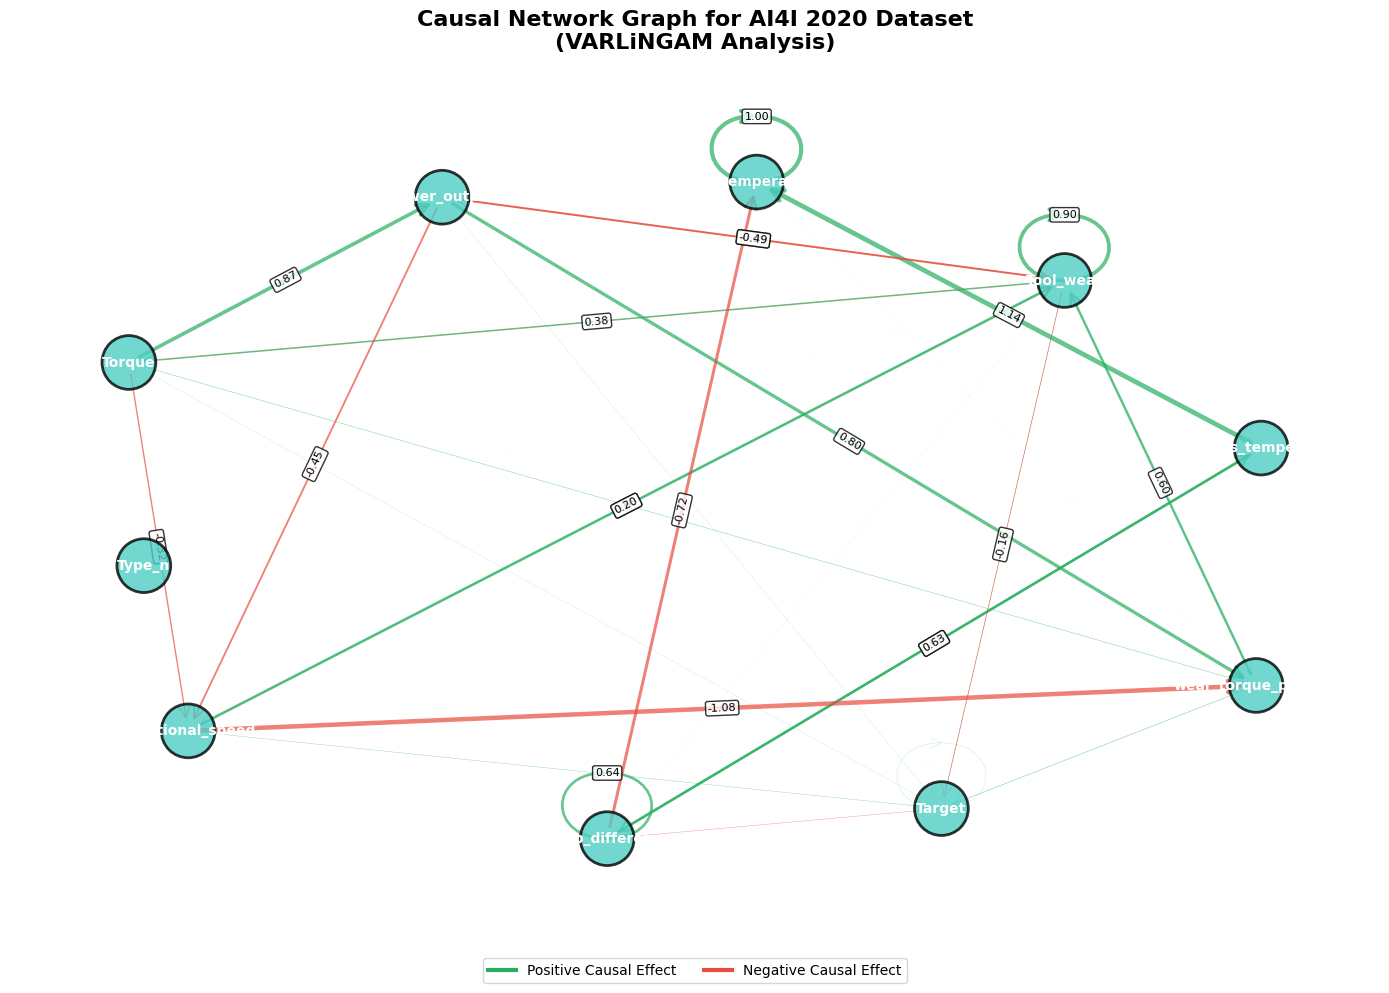


📊 CAUSALITY ANALYSIS SUMMARY:
   📁 JSON saved to: causality/causal_graph_whole_dataset.json
   📊 CSV saved to: causality/causal_graph_whole_dataset.csv
   🔗 Total causal relationships: 42

🏆 TOP 5 STRONGEST CAUSAL RELATIONSHIPS:
   1. Process_temperature → Air_temperature | Effect: +1.1358
   2. Rotational_speed ⊸ wear_torque_product | Effect: -1.0791
   3. Air_temperature → Air_temperature | Effect: +0.9994
   4. Tool_wear       → Tool_wear       | Effect: +0.8952
   5. Torque          → Power_output    | Effect: +0.8699

🎯 Target-related relationships: 10
🎯 Target relationships:
   Rotational_speed → Target          | Effect: +0.0758
   Torque          → Target          | Effect: +0.0323
   Power_output    → Target          | Effect: +0.0287
   wear_torque_product → Target          | Effect: +0.0957
   Target          → Tool_wear       | Effect: +0.0665
   Tool_wear       ⊸ Target          | Effect: -0.1594
   Target          → Air_temperature | Effect: +0.0032
   Target          → 

In [8]:
# Create Causality Analysis using VARLiNGAM on Whole Dataset
print("🔗 Creating Causality Analysis for AI4I 2020 Dataset (Whole Dataset)")
print("=" * 70)

# Define save paths for causality graph
# causality_save_path = os.path.join(paths['causality_path'], 'ai4i_2020', 'causal_graph_whole_dataset.json')
# causality_csv_path = os.path.join(paths['causality_path'], 'ai4i_2020', 'causal_graph_whole_dataset.csv')
causality_save_path = 'causality/causal_graph_whole_dataset.json'
causality_csv_path = 'causality/causal_graph_whole_dataset.csv'


# Ensure the causality directory exists
os.makedirs(os.path.dirname(causality_save_path), exist_ok=True)

# Create causality analysis on the WHOLE dataset
print("🚀 Running VARLiNGAM causality analysis on whole dataset...")

try:
    causal_relationships, causality_fig = create_causality_ai4i_2020(
        df=df_processed,
        features_to_analyze=features_for_causality,
        save_path=causality_save_path,
        regularize=True,
        noise_level=1e-4,
        include_target=False  # Target is already in features_for_causality
    )
    
    print("🎉 Causality analysis completed successfully!")
    
    # Convert causal relationships to DataFrame and save as CSV
    if causal_relationships:
        causal_df = pd.DataFrame(causal_relationships)
        causal_df.to_csv(causality_csv_path, index=False)
        print(f"💾 Causality relationships saved as CSV: {causality_csv_path}")
        
        # Display the DataFrame
        print(f"\n📊 Causal Relationships DataFrame:")
        display(causal_df.head(10))
    
    # Display the causality network graph
    plt.show()
    
    # Print summary of causal relationships found
    print(f"\n📊 CAUSALITY ANALYSIS SUMMARY:")
    print(f"   📁 JSON saved to: {causality_save_path}")
    print(f"   📊 CSV saved to: {causality_csv_path}")
    print(f"   🔗 Total causal relationships: {len(causal_relationships)}")
    
    if causal_relationships:
        # Show strongest relationships
        sorted_relationships = sorted(causal_relationships, key=lambda x: abs(x['effect_strength']), reverse=True)
        print(f"\n🏆 TOP 5 STRONGEST CAUSAL RELATIONSHIPS:")
        for i, rel in enumerate(sorted_relationships[:5], 1):
            direction = "→" if rel['effect_strength'] > 0 else "⊸"
            print(f"   {i}. {rel['source_feature']:15s} {direction} {rel['target_feature']:15s} | Effect: {rel['effect_strength']:+.4f}")
        
        # Count relationships involving Target
        target_relationships = [r for r in causal_relationships if 'Target' in [r['source_feature'], r['target_feature']]]
        print(f"\n🎯 Target-related relationships: {len(target_relationships)}")
        
        if target_relationships:
            print("🎯 Target relationships:")
            for rel in target_relationships:
                direction = "→" if rel['effect_strength'] > 0 else "⊸"
                print(f"   {rel['source_feature']:15s} {direction} {rel['target_feature']:15s} | Effect: {rel['effect_strength']:+.4f}")
        
    else:
        print("⚠️  No significant causal relationships detected.")
        
except Exception as e:
    print(f"❌ Error in causality analysis: {str(e)}")
    print("This might be due to data characteristics or VARLiNGAM model constraints.")
    import traceback
    traceback.print_exc()

<br> <br> <br>


## Training Machine Learning Models




In [ ]:
def train_model_crossval(model_type: str, X_train_balanced: np.ndarray, y_train_balanced: pd.Series, n_folds=10) -> Dict:
    try:
        model_type = model_type.lower()
        model_switch = {
            "randomforest": RandomForestClassifier(random_state=42),
            "xgboost": XGBClassifier(
                random_state=42,
                eval_metric="logloss",  # Specify evaluation metric to avoid warnings
            ),
            "lgbmclassifier": LGBMClassifier(
                random_state=42,
                boosting_type="gbdt",  # Gradient Boosting Decision Trees
                n_estimators=100,  # Number of boosting rounds
                learning_rate=0.1,  # Shrinkage rate
                max_depth=-1,  # Unlimited depth
            ),
            "catboost": CatBoostClassifier(
                random_state=42,
                iterations=100,  # Number of boosting iterations
                learning_rate=0.1,
                depth=6,
                verbose=False,  # Suppress verbose output
            ),
        }
        
        # Get the model based on model_type
        model = model_switch.get(model_type)
        
        if model is None:
            raise AttributeError("Invalid model type")
            
        # Set up k-fold cross-validation
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=kf, scoring='roc_auc')
        
        # Train the final model on the entire training set
        model.fit(X_train_balanced, y_train_balanced)
        
        # Return both the model and cross-validation results
        return {
            'model': model,
            'cv_scores': cv_scores,
            'mean_cv_score': np.mean(cv_scores),
            'std_cv_score': np.std(cv_scores)
        }

    except AttributeError as e:
        print(f"Error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")
    
    return None



def exec_model_Youden_Index(model_type: str, X_train: np.ndarray, y_train: pd.Series, X_test: np.ndarray, y_test: pd.Series) -> Dict:

    try:
        # Train the model using cross-validation
        result = train_model_crossval(model_type, X_train, y_train)
        model = result['model']
        
        # Print cross-validation results
        print(f"Cross-validation results for {model_type}:")
        print(f"Mean ROC AUC: {result['mean_cv_score']:.4f} ± {result['std_cv_score']:.4f}")
        
        # Get class probabilities for the positive class
        y_proba = model.predict_proba(X_test)[:, 1]
        # Calculate the ROC AUC score
        auc_score = roc_auc_score(y_test, y_proba)
        # Normalize the AUC score
        normalized_auc = (auc_score - 0.5) / 0.5
        
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        
        # Calculate Youden's index (J = Sensitivity + Specificity - 1 = TPR - FPR)
        youden_index = tpr - fpr
        # Find the optimal threshold that maximizes the Youden index
        optimal_idx = np.argmax(youden_index)
        optimal_threshold = thresholds[optimal_idx]
        
        # Calculate precision and recall at the optimal threshold
        y_pred = (y_proba >= optimal_threshold).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        # Plot the ROC curve
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
        # Mark the optimal threshold on the ROC curve
        plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=8, 
                 label=f'Optimal threshold (Youden Index)')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        # Print the results
        print(f"ROC AUC Score: {auc_score:.4f}")
        print(f"Normalized AUC Score: {normalized_auc:.4f}")
        print(f"Optimal Threshold (Youden Index): {optimal_threshold:.4f}")
        print(f"At optimal threshold - Precision: {precision:.4f}, Recall: {recall:.4f}")

        # Save the model
        with open(f"model/{model_type}.pkl", 'wb') as file:
            pickle.dump(model, file)

    except Exception as e:
        print(str(e))

    return print(f"Model {model_type} was trained successfully")

In [ ]:
X = df_processed.drop(columns=["Target", "Failure_Type"])
# y = df_processed["Target"] # y = df["Failure_Type"]
y = df_processed[["Target", "Failure_Type"]]
X_train, X_test, y_train, y_test = train_test_split(X, y["Target"], test_size=0.2, random_state=42)

In [ ]:
exec_model_Youden_Index("randomforest", X_train, y_train, X_test, y_test)

In [ ]:
exec_model_Youden_Index("xgboost", X_train, y_train, X_test, y_test)

In [ ]:
exec_model_Youden_Index("lgbmclassifier", X_train, y_train, X_test, y_test)

In [ ]:
exec_model_Youden_Index("catboost", X_train, y_train, X_test, y_test)

<br> <br> <br>

## Taxonomy

In [ ]:
def generate_taxonomy_with_groq(columns_list, api_key, model="llama3-70b-8192", output_file="groq_taxonomy.json"):
    output_file = f"{output_file}"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}

    # API endpoint
    endpoint = "https://api.groq.com/openai/v1/chat/completions"

    # Create the prompt for the taxonomy
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]
        "Air_temperature_combination": [3, "Air_temperature"]
        
    }}

    **Input Features**:
    {', '.join(columns_list)}
    """

    # Create the request payload
    payload = {
        "model": model,  # Using the model specified as parameter
        "messages": [
            {
                "role": "system",
                "content": "You are a data scientist who organizes features into taxonomies.",
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
    }

    # Make the API call
    response = requests.post(endpoint, headers=headers, json=payload)

    if response.status_code == 200:
        result = response.json()
        content = result["choices"][0]["message"]["content"]

        # Extract JSON from the response
        json_match = re.search(r"{.*}", content, re.DOTALL)
        if json_match:
            taxonomy_json_str = json_match.group(0)
            taxonomy = json.loads(taxonomy_json_str)
        else:
            # If no JSON pattern found, try to parse the whole content
            try:
                taxonomy = json.loads(content)
            except:
                raise ValueError("Failed to parse JSON from API response")

        # Save to file
        with open(output_file, "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        error_message = f"API request failed with status code {response.status_code}"
        try:
            error_details = response.json()
            error_message += f": {error_details}"
        except:
            pass
        raise Exception(error_message)


def generate_taxonomy_with_openai_with_feature_root(filename, features, root_features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.
    - The hierachy MUST NOT include features that are not existed in the dataset's features  
      Dataset's list of feature: {features} 
    -The roots of the hierarchy are {root_features}. These features can not have parents.


    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )


def generate_taxonomy_with_openai(filename, features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )


def format_taxonomy(taxonomy_json):
    """Formats a hierarchical taxonomy into a tree-like string."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON string if needed

    # Build tree structure
    tree = defaultdict(list)
    for feature, (_, parent) in taxonomy_json.items():
        tree[parent].append(feature)

    def display_tree(parent="Root", level=0):
        """Recursively formats the tree structure with icons and connectors."""
        if parent not in tree:
            return ""

        result = ""
        for idx, child in enumerate(tree[parent]):
            is_parent = child in tree  # Check if child has further children
            icon = (
                "📂" if is_parent else "📄"
            )  # Folder for parents, file for leaf nodes
            connector = (
                "└── " if idx == len(tree[parent]) - 1 else "├── "
            )  # Tree connectors
            result += "  " * level + connector + f"{icon} {child}\n"
            result += display_tree(child, level + 1)  # Recursive call for children

        return result

    return f"\n📌 **Taxonomy Structure:**\n\n{display_tree('Root')}".strip()


def get_taxonomy_paths(taxonomy_json, node_names):
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order

    return {node: get_path(node) for node in node_names}


In [ ]:
llama3_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="llama-3.3-70b-versatile", output_file="taxonomy/llama3.json")
print(format_taxonomy(llama3_taxonomy))

In [ ]:
gemma2_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="gemma2-9b-it", output_file="taxonomy/gemma2.json")
print(format_taxonomy(gemma2_taxonomy))

In [ ]:
deepseek_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="deepseek-r1-distill-llama-70b", output_file="taxonomy/deepseek.json")
print(format_taxonomy(deepseek_taxonomy))

In [ ]:
gpt4o_taxonomy = generate_taxonomy_with_openai(filename="taxonomy/gpt4o.json", features=df_processed.columns.tolist(), openai_api_key=openai_api_key)
print(format_taxonomy(gpt4o_taxonomy))

In [ ]:
excluded_columns = ["Power_output", "wear_torque_product", "Temp_difference"]
root_features = [col for col in df_processed.columns if col not in excluded_columns]
gpt4o_taxonomy_with_feature_roow = generate_taxonomy_with_openai_with_feature_root(filename="taxonomy/gpt4o_with_feature_root.json", 
                                                                                   features=df_processed.columns.tolist(), 
                                                                                   root_features = root_features,
                                                                                   openai_api_key=openai_api_key)

print(format_taxonomy(gpt4o_taxonomy_with_feature_roow))

<br> <br> <br>

#### Calculate the intra homogenity


In [ ]:
def calculate_intra_group_homogeneity(taxonomy, df):
    """
    Calculate intra-group homogeneity scores based on correlation within taxonomy groups

    Parameters:
    taxonomy (dict): Dictionary with features as keys and [level, parent] as values
    df (pd.DataFrame): DataFrame containing the feature data

    Returns:
    dict: Dictionary with group names as keys and homogeneity scores as values
    """
    # Extract groups from taxonomy
    groups = {}
    for feature, (level, parent) in taxonomy.items():
        if feature in df.columns:  # Only consider features present in the dataframe
            if parent not in groups:
                groups[parent] = []
            groups[parent].append(feature)

    # Calculate homogeneity scores for each group
    homogeneity_scores = {}
    # Get only numeric columns from df
    numeric_df = df.select_dtypes(include=["number"])

    for parent, features in groups.items():
        # Filter to include only numeric features
        numeric_features = [f for f in features if f in numeric_df.columns]

        # Only calculate for groups with multiple numeric features
        if len(numeric_features) > 1:
            # Get the correlation matrix for features in this group
            corr_matrix = numeric_df[numeric_features].corr().abs()

            # Calculate the average correlation (excluding self-correlations)
            total_corr = 0
            count = 0
            for i in range(len(numeric_features)):
                for j in range(i + 1, len(numeric_features)):
                    total_corr += corr_matrix.iloc[i, j]
                    count += 1

            avg_corr = total_corr / count if count > 0 else 0
            homogeneity_scores[parent] = avg_corr

    return homogeneity_scores


In [ ]:
gpt4o_homogeneity = calculate_intra_group_homogeneity(gpt4o_taxonomy, df_processed)
gpt4o_homogeneity = calculate_intra_group_homogeneity(gpt4o_taxonomy, df_processed)
llama33_homogeneity = calculate_intra_group_homogeneity(llama3_taxonomy, df_processed)
gemma2_homogeneity = calculate_intra_group_homogeneity(gemma2_taxonomy, df_processed)
deepseek_homogeneity = calculate_intra_group_homogeneity(deepseek_taxonomy, df_processed)

# Compare homogeneity scores
print("\n--- Intra-Group Homogeneity Comparison ---")

print("\nOpenAI Taxonomy Homogeneity Scores:")
for group, score in sorted(gpt4o_homogeneity.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {score:.4f}")

print("\nLlama 3.3 Taxonomy Homogeneity Scores:")
for group, score in sorted(llama33_homogeneity.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {score:.4f}")

print("\nGemma2 Taxonomy Homogeneity Scores:")
for group, score in sorted(gemma2_homogeneity.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {score:.4f}")

print("\nDeepSeek Taxonomy Homogeneity Scores:")
for group, score in sorted(deepseek_homogeneity.items(), key=lambda x: x[1], reverse=True):
    print(f"{group}: {score:.4f}")


# Calculate average homogeneity for each taxonomy
avg_openai = sum(gpt4o_homogeneity.values()) / len(gpt4o_homogeneity) if gpt4o_homogeneity else 0
avg_llama33 = sum(llama33_homogeneity.values()) / len(llama33_homogeneity) if llama33_homogeneity else 0
avg_gemma2 = sum(gemma2_homogeneity.values()) / len(gemma2_homogeneity) if gemma2_homogeneity else 0
avg_deepseek = sum(deepseek_homogeneity.values()) / len(deepseek_homogeneity) if deepseek_homogeneity else 0

print(f"\nAverage Homogeneity - OpenAI: {round(avg_openai, 2)}, Llama 3.3: {round(avg_llama33, 2)}, Gemma2: {round(avg_gemma2, 2)}, DeepSeek: {round(avg_deepseek, 2)}")

In [ ]:
def get_taxonomy_paths(taxonomy_json, node_names):
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order
    return {node: get_path(node) for node in node_names}


<br> <br> 

## Load machine learning models

In [9]:
def load_ml_models(path):
    with open(f"{path}/randomforest.pkl", "rb") as f:
        randomforest_model = pickle.load(f)

    with open(f"{path}/xgboost.pkl", "rb") as f:
        xgboost_model = pickle.load(f)

    with open(f"{path}/catboost.pkl", "rb") as f:
        catboost_model = pickle.load(f)

    with open(f"{path}/lgbmclassifier.pkl", "rb") as f:
        lgbmclassifier_model = pickle.load(f)

    return randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model


ml_models_path = 'model/'
randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model = load_ml_models(path=ml_models_path)


<br> <br> <br>

## Choose random failure from X_test

In [10]:
def build_failure_sample(
    df_processed: pd.DataFrame,
    X_test: pd.DataFrame,
    target_col: str = "Target",
    failure_col: str = "Failure_Type",
    per_type: int = 10,
    special_rules: dict | None = None,
    random_state: int = 42,
    shuffle_within: bool = True,
    return_features_only: bool = False
) -> pd.DataFrame:
    """
    Build a balanced (or rule-based) failure sample from the X_test portion
    of the processed dataframe.
    """
    if special_rules is None:
        special_rules = {}

    # Validate required columns exist
    required_cols = [target_col, failure_col]
    missing = [c for c in required_cols if c not in df_processed.columns]
    if missing:
        raise ValueError(f"Missing required columns in df_processed: {missing}")

    # Ensure X_test indices exist in df_processed
    missing_indices = set(X_test.index) - set(df_processed.index)
    if missing_indices:
        raise ValueError(f"X_test contains indices not found in df_processed: {list(missing_indices)[:5]}...")

    # Filter df_processed to only include rows that are in X_test
    test_full = df_processed.loc[X_test.index].copy()
    
    # Verify we have the same number of rows
    assert len(test_full) == len(X_test), f"Mismatch: test_full has {len(test_full)} rows, X_test has {len(X_test)} rows"

    # Filter to only failure cases (target == 1)
    failures = test_full[test_full[target_col] == 1].copy()
    if failures.empty:
        raise ValueError("No failure rows (target==1) found in X_test subset.")

    print(f"📊 Found {len(failures)} failure rows in X_test")
    print(f"📊 Failure type distribution:")
    print(failures[failure_col].value_counts())

    # Set random seed for reproducibility
    np.random.seed(random_state)
    sampled_groups = []

    for ftype, grp in failures.groupby(failure_col):
        rule = special_rules.get(ftype, per_type)
        if (rule is None) or (isinstance(rule, (int, float)) and rule <= 0):
            # Take all available rows for this failure type
            take_n = len(grp)
        else:
            # Take specified number or all available (whichever is smaller)
            take_n = min(int(rule), len(grp))

        if take_n < len(grp) and shuffle_within:
            # Randomly sample the specified number
            sampled = grp.sample(n=take_n, random_state=random_state)
        else:
            # Take all available or take first n rows
            sampled = grp if take_n == len(grp) else grp.head(take_n)

        sampled_groups.append(sampled)
        print(f"   {ftype}: selected {len(sampled)}/{len(grp)} rows")

    if not sampled_groups:
        raise ValueError("No samples were selected from any failure type")

    # Combine all sampled groups
    sampled_df = pd.concat(sampled_groups, axis=0)
    
    # Sort by failure type for better readability - DON'T reset index
    sampled_df = sampled_df.sort_values([failure_col])

    # Verify all selected indices exist in X_test
    selected_indices = set(sampled_df.index)
    x_test_indices = set(X_test.index)
    invalid_indices = selected_indices - x_test_indices
    
    if invalid_indices:
        print(f"⚠️ Warning: Found {len(invalid_indices)} indices not in X_test: {list(invalid_indices)[:5]}")
        # Filter out invalid indices
        sampled_df = sampled_df[sampled_df.index.isin(x_test_indices)]

    # Final verification
    final_indices = set(sampled_df.index)
    assert final_indices.issubset(x_test_indices), "Some selected indices are still not in X_test"

    # Report final results
    print("=== Failure Sampling Summary ===")
    print(f"Total failure rows in X_test: {len(failures)}")
    print(f"Selected rows: {len(sampled_df)}")
    print("Final counts per failure type:")
    print(sampled_df[failure_col].value_counts())

    if return_features_only:
        feature_cols = [c for c in sampled_df.columns if c not in [target_col, failure_col]]
        return sampled_df[feature_cols].copy()

    return sampled_df


In [11]:
# Usage with verification
# selected_failures_df = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=10, special_rules={"Tool Wear Failure": None},  random_state=42)
selected_failures_df = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=1, random_state=42)
# "Tool Wear Failure": None => It means take all of them

# Additional verification step
print("\n🔍 Verification:")
if 'index' in selected_failures_df.columns:
    selected_indices = set(selected_failures_df['index'])
else:
    selected_indices = set(selected_failures_df.index)

x_test_indices = set(X_test.index)
indices_not_in_x_test = selected_indices - x_test_indices

if indices_not_in_x_test:
    print(f"❌ ERROR: {len(indices_not_in_x_test)} selected indices are NOT in X_test:")
    print(f"   Examples: {list(indices_not_in_x_test)[:10]}")
else:
    print("✅ SUCCESS: All selected indices exist in X_test")

print(f"📊 Selected indices range: {min(selected_indices)} to {max(selected_indices)}")
print(f"📊 X_test indices range: {min(x_test_indices)} to {max(x_test_indices)}")

📊 Found 66 failure rows in X_test
📊 Failure type distribution:
Heat Dissipation Failure    25
Overstrain Failure          18
Power Failure               16
Tool Wear Failure            7
Name: Failure_Type, dtype: int64
   Heat Dissipation Failure: selected 1/25 rows
   Overstrain Failure: selected 1/18 rows
   Power Failure: selected 1/16 rows
   Tool Wear Failure: selected 1/7 rows
=== Failure Sampling Summary ===
Total failure rows in X_test: 66
Selected rows: 4
Final counts per failure type:
Heat Dissipation Failure    1
Overstrain Failure          1
Power Failure               1
Tool Wear Failure           1
Name: Failure_Type, dtype: int64

🔍 Verification:
✅ SUCCESS: All selected indices exist in X_test
📊 Selected indices range: 2494 to 6799
📊 X_test indices range: 1 to 9997


In [12]:
selected_failures_df

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
4164,0.750000,0.604938,0.103609,0.600275,0.430830,0.595057,0.313845,0.177778,Heat Dissipation Failure,1,0
2494,0.413043,0.382716,0.093714,0.684066,0.818182,0.677061,0.672559,0.466667,Overstrain Failure,1,0
6799,0.630435,0.617284,0.854482,0.115385,0.395257,0.238080,0.073953,0.444444,Power Failure,1,1
4816,0.880435,0.777778,0.205471,0.440934,0.849802,0.490230,0.467873,0.222222,Tool Wear Failure,1,0


In [13]:
X_test.loc[4816]

Air_temperature        0.880435
Process_temperature    0.777778
Rotational_speed       0.205471
Torque                 0.440934
Tool_wear              0.849802
Power_output           0.490230
wear_torque_product    0.467873
Temp_difference        0.222222
Type_n                 0.000000
Name: 4816, dtype: float64

<br> <br> <br>

## Generate Expalnation, actionable recommendation and evaluatre them for Data Scientist


In [14]:
def failure_type_description(failure_type, type_n=0):
    if failure_type == "Tool Wear Failure":
        description = "Tool wear is between 200 and 240 so the machine fails and the failure type is **Tool wear Failure**"
        important_parts_description = "Tool wear is between 200 and 240, Machine fails, Failure type, Tool Wear Failure"
    elif failure_type == "Heat Dissipation Failure":
        description = "temp_difference is less than 8.6 K and the rotational speed is less than 1380 so that the machine fails and the failure type is **Heat Dissipation Failure**"
        important_parts_description = "Temperature difference is less than 8.6 K, Rotational speed is less than 1380, Failure type, Heat Dissipation Failure"
    elif failure_type == "Power Failure":
        description = "if power_output < 3500 or power_output > 9000 then the machine fails and the failure type is **Power Failure**"
        important_parts_description = "Power output is less than 3500 or greater than 9000, Power output is less than 3500, Power output is greater than 9000, Failure type, Power Failure"
    elif failure_type == "Overstrain Failure":
        if type_n == 0:
            description = "The product type is L and the product of tool wear to torque exceeds 11000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is L, Tool wear × Torque > 11,000, Machine fails, Failure type, Overstrain Failure"
        elif type_n == 1:
            description = "The product type is M and the product of tool wear to torque exceeds 12000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is M, Tool wear × Torque > 12,000, Machine fails, Failure type, Overstrain Failure"
        elif type_n == 2:
            description = "The product type is H and the product of tool wear to torque exceeds 13000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is H, Tool wear × torque > 13,000, Machine fails, Failure type, Overstrain Failure"
    else:
        description = "The machine fails based on an unknown reason and the failure type is Random Failures"
        important_parts_description = "Machine fails, Reason unknown, Failure type, Random Failures"

    return description, important_parts_description


def recom_act_tool_wear(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Develop hybrid TCN-BiLSTM models to predict wear trends using vibration, force, and temperature signals.
            B) Deploy models that trigger parameter optimization (feed, speed) in real-time to extend tool life.
        """
    elif persona == "operator":
        recommendation = """
            A) Monitor tool condition using the dashboard. Follow system prompts to adjust feed rate or spindle speed when tool wear exceeds thresholds.
            B) Replace or report worn tools based on predefined wear indicators or alerts.
        """      
    else:
        recommendation = """
            A) Deploy a hybrid Temporal Convolutional Network (TCN) and Bidirectional Long Short-Term Memory (BiLSTM) predictive model to facilitate real-time monitoring of tool wear and enable adaptive adjustments to machining parameters, such as feed rate and spindle speed, to prolong tool lifespan.
            B) Optimize the geometry of the tool, including features like rake angle and nose radius, to minimize wear rates effectively.
            """
    return recommendation


def recom_act_heat_dissipation(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Analyze thermal sensor data to detect inefficient cooling or early overheating events.
            B) Build models that correlate machining parameters with heat profiles to suggest optimal cooling strategies.
        """
    elif persona == "operator":
        recommendation = """
            A) Ensure MQL systems are filled with coolant and functioning. Check nozzle positions regularly for proper coolant access.
            B) Watch for heat alerts from sensors and pause operations if temperatures exceed safe levels.
        """
    else:
        recommendation = """
        A) Use minimum quantity lubrication (MQL) with nanofluids to enhance heat transfer efficiency. Integrate thermal sensors to monitor temperature gradients and adjust cooling dynamically

        B) Use cutting tools with surface features designed to enhance coolant access and improve heat dissipation from the cutting zone, preventing overheating when temperature differences and speeds fall below the specified thresholds.

        """
    return recommendation


def recom_act_power(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Train Random Forest or regression models to detect abnormal power usage and recommend preventive action.
            B) Use time-series models to forecast torque and rotation anomalies that indicate possible failures.
        """
    elif persona == "operator": 
        recommendation = """
            A) Use the machine interface to track power usage. Follow alerts or color-coded indicators to reduce loads or pause processes.
            B) Respond to maintenance notifications when torque or power values are outside the normal range.
        """
    else:
        recommendation = """
        A) Deploy a real-time power monitoring system integrated with machine learning algorithms, such as Random Forest, to predict and regulate power consumption, ensuring it remains within the safe operational thresholds.
        
        B) Implement a predictive maintenance framework utilizing machine learning models to continuously monitor torque and rotational speed, enabling the early detection of power deviations and facilitating dynamic adjustments to maintain power within the defined range of 3500–9000 W.
        """
    return recommendation


def recom_act_overstrain(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Analyze stress/strain sensor data to predict mechanical failure risk.
            B) Develop control logic that recommends operation pauses or speed adjustments based on torque load predictions.
        """
    elif persona == "operator":
        recommendation="""
            A) Operate within recommended torque and speed limits. Be cautious during heavy-load operations.
            B) Report any unusual vibrations or strain alarms to maintenance.
        """
    else:
        recommendation = """
        A) Employ finite element analysis (FEA) to identify critical stress points in the system and implement stress-relief heat treatments to mitigate the risk of overstrain.

        B) Integrate wear-resistant coatings in conjunction with torque-limiting algorithms to effectively reduce the likelihood of overstrain and enhance the durability of the manufacturing process.
        """
    return recommendation


def switch_recommendation_action(failure_type, persona):
    match failure_type:
        case "Tool Wear Failure":
            return recom_act_tool_wear(persona)
        case "Heat Dissipation Failure":
            return recom_act_heat_dissipation(persona)
        case "Power Failure":
            return recom_act_power(persona)
        case "Overstrain Failure":
            return recom_act_overstrain(persona)
        case _:
            return "No recommendation available for this failure type."


def extract_explanation_and_recommendation(md_file_path, random_row_index_id, df_target_1, persona="data_scientist"):
    """
    Extract explanation and recommendation from a Markdown file.

    Returns:
        tuple: (explanation, recommendation, failure_type, ground_truth, important_parts, manual_recommendation, failure_description, summary_counterfactual)
    """
    try:
        with open(md_file_path, "r", encoding="utf-8") as file:
            content = file.read()
    except Exception as e:
        print(f"Error reading file {md_file_path}: {str(e)}")
        return "", "", "", "", "", "", "", "", ""

    lines = content.split("\n")

    explanation = ""
    recommendation = ""
    important_parts = ""
    manual_recommendation = ""
    failure_description = ""
    failure_type = ""
    summary_counterfactual = ""
    causal_graph = ""

    # Track which section we're in
    current_section = None

    for i, line in enumerate(lines):
        # Check for section headers
        if "### Important Parts of Recommendation" in line:
            current_section = "important_parts"
            continue
        elif "### Manual Recommendation" in line:
            current_section = "manual_recommendation"
            continue
        elif "### Failure Description" in line:
            current_section = "failure_description"
            continue
        elif "### Failure Type" in line:
            current_section = "failure_type"
            continue
        elif "### Causal Graph" in line:
            current_section = "causal_graph"
            continue        
        elif "### Summary Counterfactual" in line:
            current_section = "summary_counterfactual"
            continue
        elif "Explanation of the Failure" in line:
            current_section = "explanation"
            continue
        elif "Actionable Recommendation" in line:
            current_section = "recommendation"
            continue
        elif line.startswith("###") or line.startswith("##") or line.startswith("---"):  # New section or separator
            current_section = None
            continue

        # Skip empty lines or section dividers
        if not line.strip() or line.strip() in ["", "---"]:
            continue

        # Collect content based on current section
        if current_section == "important_parts" and line.strip():
            important_parts += " " + line.strip()
        elif current_section == "manual_recommendation" and line.strip():
            manual_recommendation += " " + line.strip()
        elif current_section == "failure_description" and line.strip():
            failure_description += " " + line.strip()
        elif current_section == "failure_type" and line.strip():
            failure_type += " " + line.strip()
        elif current_section == "causal_graph" and line.strip():
            causal_graph += " " + line.strip()            
        elif current_section == "summary_counterfactual" and line.strip():
            summary_counterfactual += " " + line.strip()
        elif current_section == "explanation" and line.strip():
            explanation += " " + line.strip()
        elif current_section == "recommendation" and line.strip():
            recommendation += " " + line.strip()

    # Clean up the collected text
    explanation = explanation.strip()
    recommendation = recommendation.strip()
    important_parts = important_parts.strip()
    manual_recommendation = manual_recommendation.strip()
    failure_description = failure_description.strip()
    failure_type = failure_type.strip()
    summary_counterfactual = summary_counterfactual.strip()
    causal_graph = causal_graph.strip()

    # Fallback to get failure_type from dataframe if not found in file
    if not failure_type:
        failure_type = df_target_1.loc[random_row_index_id]["Failure_Type"]
    
    # Generate ground truth recommendation
    ground_truth = switch_recommendation_action(failure_type=failure_type, persona=persona)

    return explanation, recommendation, failure_type, ground_truth, important_parts, manual_recommendation, failure_description, summary_counterfactual, causal_graph


# ****************************************************** Important Parts Actionable Recommendation ******************************************************


def important_parts_recommendation(failure_type, persona="not_defined"):
    if persona == "data_scientist" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """TCN, BiLSTM, Predict wear trends, Use vibration, Use force, Use temperature signals, Deploy models, Trigger parameter optimization, Optimize feed and speed parameters, Real-time execution,"""
        # Develop hybrid TCN–BiLSTM models, Predict wear trends, Use vibration, Use force, Use temperature signals, Deploy models, Trigger parameter optimization, Optimize feed and speed parameters, Real-time execution,

        # 1. Develop hybrid TCN–BiLSTM models to predict wear trends using vibration, force, and temperature signals.
        # 2. Deploy models that trigger parameter optimization (feed, speed) in real-time
        return tool_wear_failure_important_parts  
    elif persona == "operator" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """ Monitor tool condition, Use dashboard, Adjust feed rate, Adjust spindle speed, Tool wear exceeds thresholds,"""
            # 1. Monitor tool condition using the dashboard.
            # 2. Follow system prompts to adjust feed rate or spindle speed when tool wear exceeds thresholds.
        return tool_wear_failure_important_parts  
    elif persona == "not_defined" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """ Deploy hybrid TCN–BiLSTM predictive model, Real-time monitoring of tool wear, Adaptive adjustments to machining parameters, Optimize tool geometry, Focus on rake angle, - Focus on nose radius, Minimize wear rates,"""     
            # 1. **Deploy a hybrid TCN and BiLSTM predictive model** → For **real-time monitoring** of tool wear and **adaptive adjustments** to machining parameters (feed rate, spindle speed).
            # 2. **Optimize tool geometry** → Focus on **rake angle** and **nose radius** to **minimize wear rates**.

        return tool_wear_failure_important_parts  
  

    if persona == "data_scientist" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Analyze thermal sensor data, Detect inefficient cooling, Build models, Correlate machining parameters with heat profiles, """
            # 1. Analyze thermal sensor data to detect inefficient cooling or early overheating events
            # 2. Build models that correlate machining parameters with heat profiles to suggest optimal cooling strategies

        return heat_dissipation_failure_important_parts        
    elif persona == "operator" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Ensure MQL systems are filled with coolant, Confirm MQL systems are functioning, Check nozzle positions regularly, 
        Watch for heat alerts from, sensors, Pause operations if temperatures exceed safe levels, """
        # 1. Ensure MQL systems are filled with coolant and functioning. Check nozzle positions regularly.
        # 2. Watch for heat alerts from sensors and pause operations if temperatures exceed safe levels
        return heat_dissipation_failure_important_parts
    elif persona == "not_defined" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Use minimum quantity lubrication (MQL) with nanofluids, Enhance heat transfer, Integrate thermal sensors for dynamic temperature monitoring and cooling adjustment, Use cutting tools with surface features for enhanced coolant access, Improve heat dissipation in the cutting zone, Prevent overheating when temperatures or speeds approach thresholds, """
        # 1. **Use minimum quantity lubrication (MQL) with nanofluids**  
        #     → To **enhance heat transfer**, plus **integrate thermal sensors** for **dynamic temperature monitoring and cooling adjustment**.
        #     2. **Use cutting tools with surface features for enhanced coolant access**  
        #     → Improves **heat dissipation** in the cutting zone and **prevents overheating**, especially when temps/speeds fall below thresholds.
        return heat_dissipation_failure_important_parts


    if persona == "data_scientist" and failure_type == "Power Failure":
        power_failure_important_parts = """Train regression models, Train random forest models, Use time-series models, Forecast torque anomalies, Forecast rotation anomalies,"""
        # 2. Use time-series models to forecast torque and rotation anomalies that indicate possible failures.
        return power_failure_important_parts
    elif persona == "operator" and failure_type == "Power Failure":
        power_failure_important_parts = """Use the machine interface to track power usage, Follow alerts or color-coded indicators to reduce loads or pause processes, Respond to maintenance notifications when torque or power values are outside the normal range, """
            #  1. Use the machine interface to track power usage. Follow alerts or color-coded indicators to reduce loads or pause processes.
            # 2. Respond to maintenance notifications when torque or power values are outside the normal range.

        return power_failure_important_parts
    elif persona == "not-defined" and failure_type == "Power Failure":
        power_failure_important_parts = """Deploy real-time power monitoring with ML (e.g., Random Forest), Predict and regulate power, Ensure power stays within safe thresholds,
        Implement predictive maintenance using ML to monitor torque and rotational speed, Early detection of power deviations, Dynamic adjustment targeting power range 3500–9000 W """
            # 1. **Deploy real-time power monitoring with ML (e.g., Random Forest)**  
            # → To **predict and regulate power**, ensuring it stays **within safe thresholds**.
            # 2. **Implement predictive maintenance using ML to monitor torque & rotational speed**  
            # → For **early detection of power deviations** and **dynamic adjustment**, targeting power range **3500–9000 W**.

        return power_failure_important_parts
    
    if persona == "data_scientist" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Analyze stress/strain sensor data, Predict mechanical failure risk, Develop control logic, Recommend operation pauses, Recommend speed adjustments, Base recommendations on torque load predictions
        """
            # 1. Analyze stress/strain sensor data to predict mechanical failure risk
            # 2. Develop control logic that recommends operation pauses or speed adjustments based on torque load predictions

        return overstrain_failure_important_parts
    elif persona == "operator" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Operate within recommended torque limits, Operate within recommended speed limits, Exercise caution during heavy-load operations, 
        Report unusual vibrations to maintenance, Report strain alarms to maintenance"""
        #  1. Operate within recommended torque and speed limits. Be cautious during heavy-load operations.
        #     2. Report any unusual vibrations or strain alarms to maintenance.
        return overstrain_failure_important_parts
    elif persona == "not-defined" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Use Finite Element Analysis (FEA), Identify critical stress points, Apply stress-relief heat treatments, Integrate wear-resistant coatings, 
        Integrate torque-limiting algorithms, Reduce overstrain risk, Improve durability """
        # 1. **Use Finite Element Analysis (FEA)**  
        # → To **identify critical stress points** and apply **stress-relief heat treatments**.
        # 2. **Integrate wear-resistant coatings + torque-limiting algorithms**  
        # → To **reduce overstrain risk** and **improve durability**.

        return overstrain_failure_important_parts



<br> <br> <br>

#### Counterfactuals

In [15]:

def run_advanced_counterfactuals(
    df_shap,
    structured_adjacency,
    base_row,
    model,
    num_runs=10,
    perturbation_scale=0.1,
    perturbation_method="gaussian",  # 'gaussian', 'uniform', or 'fixed'
    fixed_value=None,  # Used if method is 'fixed'
    random_seed=None,
    verbose=True,
):
    """
    Advanced counterfactual generator for SHAP-causal subgraph with improved error handling.
    Tracks feature changes, supports multiple perturbation methods, and logs model predictions.
    """
    import numpy as np
    import pandas as pd

    try:
        if random_seed is not None:
            np.random.seed(random_seed)

        # Handle both DataFrame and Series input for base_row
        if isinstance(base_row, pd.DataFrame):
            if len(base_row) == 1:
                base_row = base_row.iloc[0]  # Convert single-row DataFrame to Series
            else:
                raise ValueError("base_row DataFrame must contain exactly one row")
        elif not isinstance(base_row, pd.Series):
            raise ValueError("base_row must be a pandas Series or single-row DataFrame")

        # Get the subgraph nodes (features) from the SHAP-causal mapping
        top_features = set(df_shap["feature"])
        subgraph_nodes = set()

        # Build subgraph including causal relationships - FIX THE KEY ACCESS
        if isinstance(structured_adjacency, pd.DataFrame):
            # If it's a DataFrame, iterate through rows
            for _, edge in structured_adjacency.iterrows():
                source = edge.get("source", edge.get("source_feature", ""))
                target = edge.get("target", edge.get("target_feature", ""))
                
                if (source in top_features) or (target in top_features):
                    subgraph_nodes.add(source)
                    subgraph_nodes.add(target)
        elif isinstance(structured_adjacency, list):
            # If it's a list of dictionaries
            for edge in structured_adjacency:
                if isinstance(edge, dict):
                    # Try different possible key names
                    source = edge.get("source_feature") or edge.get("source") or ""
                    target = edge.get("target_feature") or edge.get("target") or ""
                    
                    if (source in top_features) or (target in top_features):
                        subgraph_nodes.add(source)
                        subgraph_nodes.add(target)
                else:
                    # Handle case where edge might be a string or other format
                    if verbose:
                        print(f"Warning: Unexpected edge format: {type(edge)} - {edge}")
                    continue
        else:
            if verbose:
                print(f"Warning: Unexpected structured_adjacency format: {type(structured_adjacency)}")

        # Filter to only include nodes that exist in base_row
        subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]

        if not subgraph_nodes:
            if verbose:
                print("Warning: No subgraph nodes found in base_row. Using top_features only.")
            subgraph_nodes = [f for f in top_features if f in base_row.index]

        if not subgraph_nodes:
            raise ValueError("No valid features found in base_row that match SHAP features")

        # Store original values for all features (not just subgraph)
        base_values = base_row.copy()
        feature_names = model.feature_names_

        # Validate that all required features are present
        missing_features = [f for f in feature_names if f not in base_row.index]
        if missing_features and verbose:
            print(f"Warning: Missing features in base_row: {missing_features}")

        counterfactual_results = []
        logs = []
        successful_runs = 0

        # Get original prediction for comparison
        try:
            original_input = pd.DataFrame(
                [
                    {
                        feat: base_row[feat] if feat in base_row.index else 0.0
                        for feat in feature_names
                    }
                ]
            )
            original_input = original_input.apply(pd.to_numeric, errors="coerce").fillna(0)
            original_prediction = model.predict(original_input)[0]
            original_proba = model.predict_proba(original_input)[0]
            if verbose:
                print(f"Original prediction: {original_prediction} (confidence: {max(original_proba):.4f})")
        except Exception as e:
            if verbose:
                print(f"Warning: Could not get original prediction: {e}")
            original_prediction = None
            original_proba = None

        for i in range(num_runs):
            try:
                # Start with a copy of all original values
                perturbed_full = base_values.copy()
                feature_changes = []

                if verbose and i < 5:  # Only print first 5 runs to avoid spam
                    print(f"\nCounterfactual run {i+1}:")

                # Perturb only top SHAP features that exist in the data
                for feat in top_features:
                    if feat in perturbed_full.index:
                        old_value = perturbed_full[feat]

                        # Choose perturbation method
                        if perturbation_method == "gaussian":
                            # Use feature's own standard deviation or SHAP importance as guide
                            # FIX: Check for correct column name
                            importance_col = None
                            for col_name in ['feature_importance', 'importance', 'shap_value']:
                                if col_name in df_shap.columns:
                                    importance_col = col_name
                                    break
                            
                            if importance_col:
                                feat_importance = df_shap[df_shap["feature"] == feat][importance_col]
                                if not feat_importance.empty:
                                    # Scale perturbation by feature importance
                                    importance_weight = feat_importance.iloc[0]
                                    std = max(0.01, abs(old_value) * 0.1)  # 10% of current value as base std
                                    noise = np.random.normal(0, perturbation_scale * std * importance_weight)
                                else:
                                    noise = np.random.normal(0, perturbation_scale * max(0.01, abs(old_value) * 0.1))
                            else:
                                noise = np.random.normal(0, perturbation_scale * max(0.01, abs(old_value) * 0.1))
                            new_value = old_value + noise

                        elif perturbation_method == "uniform":
                            # Scale uniform perturbation by current value
                            range_scale = max(0.01, abs(old_value) * 0.2)  # 20% of current value as range
                            noise = np.random.uniform(
                                -perturbation_scale * range_scale,
                                perturbation_scale * range_scale,
                            )
                            new_value = old_value + noise

                        elif perturbation_method == "fixed":
                            new_value = fixed_value if fixed_value is not None else old_value
                            noise = new_value - old_value

                        else:
                            raise ValueError(f"Unknown perturbation_method: {perturbation_method}")

                        perturbed_full[feat] = new_value
                        feature_changes.append(
                            {
                                "feature": feat,
                                "old_value": old_value,
                                "new_value": new_value,
                                "perturbation": noise,
                                "perturbation_percent": (
                                    (noise / old_value * 100) if old_value != 0 else 0
                                ),
                            }
                        )

                        if verbose and i < 5:
                            print(
                                f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} "
                                f"(Δ={noise:.6f}, {noise/old_value*100:.2f}%)"
                                if old_value != 0
                                else f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} (Δ={noise:.6f})"
                            )

                # Prepare input for model prediction
                model_input = {}
                for feat in feature_names:
                    if feat in perturbed_full.index:
                        model_input[feat] = perturbed_full[feat]
                    else:
                        # Use zero for missing features
                        model_input[feat] = 0.0
                        if verbose and i < 3:  # Only warn for first few runs
                            print(f"  Warning: Missing feature '{feat}', using default value 0.0")

                X_input = pd.DataFrame([model_input])
                X_input = X_input.apply(pd.to_numeric, errors="coerce").fillna(0)

                # Make prediction
                try:
                    y_pred = model.predict(X_input)[0]
                    y_pred_proba = model.predict_proba(X_input)[0]
                    successful_runs += 1

                    # Check if prediction changed from original
                    prediction_changed = (
                        original_prediction is not None and y_pred != original_prediction
                    )

                except Exception as pred_error:
                    if verbose and i < 3:
                        print(f"  Prediction error in run {i+1}: {pred_error}")
                    y_pred = None
                    y_pred_proba = None
                    prediction_changed = False

                # Store only the perturbed features for analysis
                perturbed_subset = {feat: perturbed_full[feat] for feat in subgraph_nodes}
                counterfactual_results.append(perturbed_subset)

                logs.append(
                    {
                        "run": i + 1,
                        "feature_changes": feature_changes,
                        "model_prediction": y_pred,
                        "model_prediction_proba": (
                            y_pred_proba.tolist() if y_pred_proba is not None else None
                        ),
                        "prediction_changed": prediction_changed,
                        "success": y_pred is not None,
                        "num_features_changed": len(feature_changes),
                    }
                )

            except Exception as run_error:
                if verbose:
                    print(f"  Error in run {i+1}: {run_error}")
                logs.append(
                    {
                        "run": i + 1,
                        "feature_changes": [],
                        "model_prediction": None,
                        "model_prediction_proba": None,
                        "prediction_changed": False,
                        "success": False,
                        "error": str(run_error),
                        "num_features_changed": 0,
                    }
                )

        # Create results DataFrame
        if counterfactual_results:
            cf_df = pd.DataFrame(counterfactual_results)
        else:
            cf_df = pd.DataFrame()

        # Find consistent nodes: nodes whose value is (almost) the same across all runs
        consistent_nodes = {}
        if not cf_df.empty:
            for col in cf_df.columns:
                values = cf_df[col].values
                if len(values) > 1 and np.allclose(values, values[0], atol=1e-4):
                    consistent_nodes[col] = values[0]
                elif len(values) == 1:
                    consistent_nodes[col] = values[0]

        if verbose:
            print(f"\nCompleted {successful_runs}/{num_runs} successful counterfactual runs.")

            # Enhanced summary statistics
            print("\n=== Counterfactual Summary ===")

            # Feature change statistics
            for feat in top_features:
                changes = [
                    chg
                    for log in logs
                    for chg in log.get("feature_changes", [])
                    if chg["feature"] == feat
                ]
                if changes:
                    avg_perturb = np.mean([abs(chg["perturbation"]) for chg in changes])
                    avg_percent = np.mean([abs(chg["perturbation_percent"]) for chg in changes])
                    print(
                        f"Feature '{feat}': changed {len(changes)} times, "
                        f"avg |perturbation|={avg_perturb:.4f} ({avg_percent:.2f}%)"
                    )

            # Model predictions summary
            preds = [log["model_prediction"] for log in logs if log["model_prediction"] is not None]
            if preds:
                unique, counts = np.unique(preds, return_counts=True)
                pred_dict = dict(zip(unique, counts))
                print("Model predictions across runs:", pred_dict)

                # Prediction change analysis
                changes = [log["prediction_changed"] for log in logs if log["success"]]
                if changes:
                    change_rate = sum(changes) / len(changes) * 100
                    print(f"Prediction changed in {sum(changes)}/{len(changes)} runs ({change_rate:.1f}%)")
            else:
                print("No successful model predictions.")

            # Show consistent features
            if consistent_nodes:
                print(f"\nConsistent features across all runs:")
                for node, value in list(consistent_nodes.items()):
                    print(f"  {node}: {value:.6f}")

        return consistent_nodes, cf_df, logs

    except Exception as e:
        if verbose:
            print(f"Critical error in run_advanced_counterfactuals: {e}")
        return {}, pd.DataFrame(), []


def safe_counterfactual_analysis(
    X_test,
    y_test,
    df_shap,
    structured_adjacency,
    model,
    num_runs=100,
    specific_row_index=None,
    uncertainty_threshold=None,
):
    """
    Enhanced wrapper function to safely run counterfactual analysis with better row selection options.

    Args:
        X_test (pd.DataFrame): Test features
        y_test (array-like): Test labels
        df_shap (pd.DataFrame): SHAP features
        structured_adjacency (list): Causal relationships
        model: Trained model
        num_runs (int): Number of counterfactual runs
        specific_row_index (int): Specific row index to analyze (optional)
        uncertainty_threshold (float): If provided, select uncertain predictions only

    Returns:
        tuple: (consistent_nodes, all_counterfactuals, logs, selected_row, row_info)
    """
    try:
        # Validate inputs
        if len(X_test) == 0:
            raise ValueError("X_test is empty")

        if df_shap.empty or "feature" not in df_shap.columns:
            raise ValueError("Invalid df_shap DataFrame")

        # Row selection logic
        row_info = {}

        if specific_row_index is not None:
            # Use specific row if provided
            if specific_row_index not in X_test.index:
                raise ValueError(f"Row index {specific_row_index} not found in X_test")
            random_row = X_test.loc[specific_row_index]
            row_info["selection_method"] = "specific"
            row_info["index"] = specific_row_index

        elif uncertainty_threshold is not None:
            # Select from uncertain predictions
            try:
                probs = model.predict_proba(X_test)
                max_probs = probs.max(axis=1)
                uncertain_mask = max_probs < uncertainty_threshold

                if not uncertain_mask.any():
                    print(
                        f"No uncertain predictions found with threshold {uncertainty_threshold}. Using random selection."
                    )
                    random_idx = np.random.randint(0, len(X_test))
                    random_row = X_test.iloc[random_idx]
                    row_info["selection_method"] = "random_fallback"
                else:
                    uncertain_indices = X_test.index[uncertain_mask]
                    selected_idx = np.random.choice(uncertain_indices)
                    random_row = X_test.loc[selected_idx]
                    row_info["selection_method"] = "uncertain"
                    row_info["uncertainty_threshold"] = uncertainty_threshold
                    row_info["max_probability"] = max_probs[
                        X_test.index.get_loc(selected_idx)
                    ]

                row_info["index"] = random_row.name

            except Exception as e:
                print(
                    f"Error in uncertainty-based selection: {e}. Using random selection."
                )
                random_idx = np.random.randint(0, len(X_test))
                random_row = X_test.iloc[random_idx]
                row_info["selection_method"] = "random_fallback"
                row_info["index"] = random_row.name
        else:
            # Random selection (default)
            random_idx = np.random.randint(0, len(X_test))
            random_row = X_test.iloc[random_idx]
            row_info["selection_method"] = "random"
            row_info["index"] = random_row.name

        # Get additional row information
        try:
            if hasattr(y_test, "iloc"):
                true_label = y_test.iloc[X_test.index.get_loc(random_row.name)]
            else:
                true_label = y_test[X_test.index.get_loc(random_row.name)]
            row_info["true_label"] = true_label

            # Get model prediction for this row
            pred = model.predict(random_row.to_frame().T)[0]
            pred_proba = model.predict_proba(random_row.to_frame().T)[0]
            row_info["predicted_label"] = pred
            row_info["prediction_confidence"] = max(pred_proba)

        except Exception as e:
            print(f"Warning: Could not get prediction info: {e}")
            row_info["true_label"] = None
            row_info["predicted_label"] = None
            row_info["prediction_confidence"] = None

        print(
            f"Selected row at index {row_info['index']} using {row_info['selection_method']} method"
        )
        if (
            row_info.get("true_label") is not None
            and row_info.get("predicted_label") is not None
        ):
            print(
                f"True label: {row_info['true_label']}, "
                f"Predicted: {row_info['predicted_label']} "
                f"(confidence: {row_info.get('prediction_confidence', 0):.4f})"
            )

        # Run counterfactual analysis
        consistent_nodes, all_counterfactuals, logs = run_advanced_counterfactuals(
            df_shap=df_shap,
            structured_adjacency=structured_adjacency,
            base_row=random_row,
            # model_dict={"model": model, "feature_names": model.feature_names_in_},
            model = model,
            num_runs=num_runs,
            perturbation_scale=0.1,
            perturbation_method="gaussian",
            random_seed=42,
            verbose=True,
        )

        return consistent_nodes, all_counterfactuals, logs, random_row, row_info

    except Exception as e:
        print(f"Error in safe_counterfactual_analysis: {e}")
        return {}, pd.DataFrame(), [], None, {}


# Additional utility function for better counterfactual summary
def generate_enhanced_counterfactual_summary(
    consistent_nodes,
    all_counterfactuals,
    logs,
    max_features=10,
    include_statistics=True,
):
    """
    Enhanced version of counterfactual summary with more detailed statistics.

    Args:
        consistent_nodes (dict): Features stable across all counterfactuals
        all_counterfactuals (pd.DataFrame): All counterfactual samples
        logs (list): Detailed logs from counterfactual runs
        max_features (int): Maximum features to include in summary
        include_statistics (bool): Whether to include detailed statistics

    Returns:
        str: Enhanced human-readable summary
    """
    # Basic summary components
    stable = list(consistent_nodes.keys())
    stable_str = (
        f"Stable features (not needing change): {', '.join(map(str, stable[:max_features]))}."
        if stable
        else "No features remained completely stable across counterfactuals."
    )

    # Feature change analysis
    feature_change_counts = {}
    feature_avg_perturbations = {}

    for log in logs:
        for chg in log.get("feature_changes", []):
            feat = chg["feature"]
            feature_change_counts[feat] = feature_change_counts.get(feat, 0) + 1
            if feat not in feature_avg_perturbations:
                feature_avg_perturbations[feat] = []
            feature_avg_perturbations[feat].append(abs(chg.get("perturbation", 0)))

    if feature_change_counts:
        sorted_features = sorted(
            feature_change_counts.items(), key=lambda x: x[1], reverse=True
        )
        top_changed = [f"{f} (changed {c}x)" for f, c in sorted_features[:max_features]]
        changed_str = f"Most sensitive features: {', '.join(top_changed)}."
    else:
        changed_str = "No feature changes detected in counterfactuals."

    # Prediction analysis
    preds = [
        log.get("model_prediction")
        for log in logs
        if log.get("model_prediction") is not None
    ]
    successful_runs = len([log for log in logs if log.get("success", False)])
    total_runs = len(logs)

    if preds:
        from collections import Counter

        pred_counts = Counter(preds)
        pred_str = f"Model predictions across counterfactuals: {', '.join([f'{k}: {v}' for k, v in pred_counts.items()])}."

        # Prediction change analysis
        changes = [
            log.get("prediction_changed", False)
            for log in logs
            if log.get("success", False)
        ]
        if changes:
            change_rate = sum(changes) / len(changes) * 100 if changes else 0
            if change_rate > 50:
                robustness_str = f"Model prediction is sensitive to feature changes ({change_rate:.1f}% of runs changed prediction)."
            elif change_rate > 10:
                robustness_str = f"Model prediction shows moderate sensitivity to feature changes ({change_rate:.1f}% changed)."
            else:
                robustness_str = "Model prediction is robust to most feature changes."
        else:
            robustness_str = "Model prediction robustness could not be determined."
    else:
        pred_str = "No model predictions available for counterfactuals."
        robustness_str = ""

    # Success rate
    success_str = (
        f"Successfully completed {successful_runs}/{total_runs} counterfactual runs."
    )

    # Combine all parts
    parts = [
        part
        for part in [stable_str, changed_str, pred_str, robustness_str, success_str]
        if part
    ]
    summary = " ".join(parts)

    return summary

## **Key Parts of Code for Counterfactual Calculation**

Inside `run_advanced_counterfactuals()`:

1. **Factual Selection**

   ```python
   factual = X.iloc[[index]]
   factual_pred = model.predict_proba(factual)[:, 1]
   ```

   This picks the target row and gets its probability.

2. **Optimization Loop**

   ```python
   for feature in mutable_features:
       # adjust value
       candidate = factual.copy()
       candidate[feature] += step
       pred = model.predict_proba(candidate)[:, 1]
       ...
   ```

   This is where the actual counterfactual search happens.

3. **Distance Measurement**

   ```python
   distance = np.linalg.norm(candidate - factual, ord=1)  # L1 distance
   ```

   Used to ensure minimal change.

4. **Final Selection**

   ```python
   if pred >= desired_threshold and distance < best_distance:
       best_candidate = candidate
   ```

   Keeps the closest valid counterfactual.

<br> <br> <br>

## SHAP

In [16]:
# ************************************************************** SHAP Feature Importance ****************************************************************

def generate_shap_values(model, random_sample, image_name, combined_feature_importance_name, top_n_features=3, class_idx=1, x_axis_labelsize=15, y_axis_labelsize=15, off_switch=False,):
    
    # Generate SHAP values for the sample
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(random_sample)

    # Handle SHAP values based on their structure and model type
    if isinstance(shap_values, list):
        # For models that return a list of arrays (like RF, XGB, LGBM for binary classification)
        feature_importance = np.abs(shap_values[class_idx]).mean(axis=0)
    else:
        # For models that return a single array
        feature_importance = np.abs(shap_values).mean(axis=0)

    # Create DataFrame with feature importances
    shap_feature_importance = pd.DataFrame(
        {"feature": random_sample.columns, "importance": feature_importance}
    )
    shap_feature_importance = shap_feature_importance.sort_values(
        "importance", ascending=False
    )

    # Display the top N important features in a DataFrame
    combined_feature_importance = pd.DataFrame(
        {
            "feature": shap_feature_importance["feature"][:top_n_features].tolist(),
            "importance": shap_feature_importance["importance"][
                :top_n_features
            ].tolist(),
        }
    ).sort_values("importance", ascending=False)

    # Save the combined feature importance DataFrame to a JSON file
    combined_feature_importance.to_json(f"json/{combined_feature_importance_name}.json", orient="records")

    # Get prediction probabilities for the sample
    pred_shap = model.predict_proba(random_sample)[0]

    # Plot the top features and their SHAP values
    plt.figure(figsize=(10, 6))
    plt.barh(
        shap_feature_importance["feature"][:top_n_features][::-1],
        shap_feature_importance["importance"][:top_n_features][::-1],
    )
    # plt.title(f"Top {top_n_features} Important Features from {combined_feature_importance_name}", fontsize=18)
    plt.title(f"Top {top_n_features} Important Features", fontsize=15)
    # plt.xlabel("SHAP Value (absolute)", fontsize=16)

    # Set different font sizes for x-axis and y-axis
    plt.tick_params(
        axis="x", which="major", labelsize=x_axis_labelsize
    )  # X-axis font size
    plt.tick_params(
        axis="y", which="major", labelsize=y_axis_labelsize
    )  # Y-axis font size

    # Format x-axis to have only 2 decimal places
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(image_name)

    if off_switch:
        plt.close()
    else:
        plt.show()

    return shap_values, pred_shap, combined_feature_importance


In [17]:
# ************************************************* Display Causality **************************************************

def display_causality_among_features_and_target(causal_graph, features_to_analyze, combined_feature_importance, edge_threshold=None, use_edge_threshold=False, draw_label=True, 
                                                node_font_size=9, node_size=1500, save_path=None, off_switch=False,):

    with open(f"{causal_graph}", "r") as file:
        causal_graph_data = json.load(file)

    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes and collect edges
    G.add_node("Target", type="target")
    for feature in features_to_analyze:
        G.add_node(feature, type="feature")

    # Process edges
    edges_info = []
    target_edges_info = []

    # Filter threshold for edge visibility - only show stronger effects
    edge_threshold = edge_threshold

    for edge in causal_graph_data:
        source = edge["source_feature"]
        target = edge["target_feature"]
        effect = round(edge["effect_strength"], 2)

        if (
            (source in features_to_analyze or source == "Target")
            and (target in features_to_analyze or target == "Target")
            and (
                not use_edge_threshold
                or (abs(effect) >= edge_threshold and abs(effect) != 0.0)
            )
        ):
            is_target_edge = source == "Target" or target == "Target"
            edge_data = {
                "source": source,
                "target": target,
                "effect_strength": effect,
                "is_target": is_target_edge,
            }

            # Store the effect
            G.add_edge(
                source,
                target,
                weight=abs(effect),
                effect=effect,
                is_target=is_target_edge,
            )

            if is_target_edge:
                target_edges_info.append(edge_data)
            else:
                edges_info.append(edge_data)

    # Create DataFrame for edges
    all_edges_info = edges_info + target_edges_info
    causality_df = (
        pd.DataFrame(all_edges_info)
        if all_edges_info
        else pd.DataFrame(columns=["source", "target", "effect_strength", "is_target"])
    )

    # Set node attributes with configurable size
    feature_importance_dict = combined_feature_importance.set_index("feature")[
        "importance"
    ].to_dict()
    node_attrs = {}

    for node in G.nodes():
        if node == "Target":
            node_attrs[node] = {
                "size": node_size,  # Use parameter instead of fixed value
                "color": "#FF5555",  # Red for target
                "label": "Target",
                "importance": 1.0,
            }
        else:
            importance = feature_importance_dict.get(node, 0.01)
            node_attrs[node] = {
                "size": node_size,  # Use parameter instead of fixed value
                "color": "#5599FF",  # Blue for features
                "label": node,
                "importance": importance,
            }

    # Set up the plot with a clear background
    plt.figure(figsize=(14, 10), facecolor="white")

    # Choose optimal layout
    pos = nx.spring_layout(G, k=1.0, iterations=100, seed=42)

    # Improved node separation algorithm
    def get_node_radius(node):
        return np.sqrt(node_attrs[node]["size"] / np.pi) / 100

    # Apply force-directed algorithm to reduce node overlaps
    for _ in range(100):  # More iterations for better convergence
        displacement = {node: np.array([0.0, 0.0]) for node in G.nodes()}

        # Calculate repulsive forces
        for node1 in G.nodes():
            for node2 in G.nodes():
                if node1 != node2:
                    delta = np.array(pos[node1]) - np.array(pos[node2])
                    distance = max(0.01, np.linalg.norm(delta))

                    # Calculate repulsion based on node sizes
                    min_distance = (
                        get_node_radius(node1) + get_node_radius(node2) + 0.05
                    )

                    if distance < min_distance:
                        # Normalize direction vector
                        direction = (
                            delta / distance if distance > 0 else np.array([1.0, 0.0])
                        )
                        # Force is stronger when nodes are closer
                        force = min(0.1, (min_distance - distance) / min_distance) * 0.2
                        displacement[node1] += direction * force
                        displacement[node2] -= direction * force

        # Apply displacements
        for node in G.nodes():
            if node != "Target":  # Keep target node fixed
                pos[node] = np.array(pos[node]) + displacement[node]

    # Draw nodes with clear boundaries
    node_sizes = [node_attrs[node]["size"] for node in G.nodes()]
    node_colors = [node_attrs[node]["color"] for node in G.nodes()]
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.8,
        edgecolors="black",
        linewidths=1.5,
    )

    # Separate edges by type
    regular_edges = [
        (u, v) for u, v, d in G.edges(data=True) if not d.get("is_target", False)
    ]
    target_edges = [
        (u, v) for u, v, d in G.edges(data=True) if d.get("is_target", True)
    ]

    # Draw regular edges with clearer styling
    if regular_edges:
        regular_weights = [
            min(3, max(1, abs(G[u][v]["effect"]) * 2)) for u, v in regular_edges
        ]
        regular_colors = [
            "#DD8888" if G[u][v]["effect"] < 0 else "#88DD88" for u, v in regular_edges
        ]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=regular_edges,
            width=regular_weights,
            edge_color=regular_colors,
            arrowsize=12,
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            alpha=0.7,
        )

    # Draw target edges with more prominent style
    if target_edges:
        target_weights = [
            min(5, max(2, abs(G[u][v]["effect"]) * 4)) for u, v in target_edges
        ]
        target_colors = [
            "#9966CC" if G[u][v]["effect"] < 0 else "#FF9900" for u, v in target_edges
        ]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=target_edges,
            width=target_weights,
            edge_color=target_colors,
            arrowsize=15,
            arrowstyle="->",
            connectionstyle="arc3,rad=0.2",
        )

    # Draw labels with better positioning and offset from nodes
    label_pos = {node: (pos[node][0], pos[node][1] + 0.02) for node in G.nodes()}
    nx.draw_networkx_labels(
        G,
        label_pos,
        font_size=node_font_size,
        font_family="sans-serif",
        font_weight="bold",
        font_color="black",
    )

    # Only show edge labels for the most important relationships
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        # Show labels only for stronger effects or target connections
        if abs(data["effect"]) > 0.3 or data.get("is_target", False):
            edge_labels[(u, v)] = f"{data['effect']:.2f}"

    # Draw edge labels with better visibility - scale edge label font based on node font size
    edge_font_size = max(8, int(node_font_size * 0.9))
    if draw_label:
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=edge_font_size,
            font_color="black",
            bbox=dict(facecolor="white", alpha=0.8),
            label_pos=0.6,
        )

    # Add a clear title
    plt.title(
        "Causal Relationships Between Features and Target",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # Scale legend font size based on node font size
    legend_font_size = max(9, int(node_font_size))
    # Add a more compact legend in a better position
    legend_elements = [
        plt.Line2D([0], [0], color="#88DD88", linewidth=3, label="Positive Effect"),
        plt.Line2D([0], [0], color="#DD8888", linewidth=3, label="Negative Effect"),
        plt.Line2D([0], [0], color="#FF9900", linewidth=4, label="Pos. Target Effect"),
        plt.Line2D([0], [0], color="#9966CC", linewidth=4, label="Neg. Target Effect"),
    ]

    # Place legend outside the plot area
    plt.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
        frameon=True,
        fontsize=legend_font_size,
    )

    plt.axis("off")
    plt.tight_layout()

    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if off_switch:
        plt.close()
    else:
        plt.show()

    return causality_df


In [44]:
def generate_explanation_actionable_recommendation_using_openai( 
    failure_type,
    failure_description,
    feature_values,
    causal_graph,
    recommended_action,
    important_actions,
    counterfactual_summary,
    response_folder,
    random_row_index_id,
    openai_api_key,
    persona,
    # Add these new parameters
    important_parts=None,
    manual_recommendation=None,
):
    prompt = f"""
    **Task:**

    You are assisting a **{persona}** in understanding why a predictive maintenance system detected a **{failure_type}**, and what actions they should take to prevent it in the future.

    Use the following input data:

    - Failure description: {failure_description}
    - Sensor values (features): {feature_values}
    - Causal relationships (including effect_strengths) in JSON format: {causal_graph}
    - Recommended action: {recommended_action}

    ---

    **Instructions:**

    Tailor your explanation and advice for a **{persona}**. Adjust your tone, depth, and focus accordingly:

    - If the persona is an **Operator**: Use plain language, avoid technical jargon, and focus on clear, actionable steps for day-to-day machine use and maintenance.
    - If the persona is a **Machine Designer**: Include technical insights that relate to mechanical structure, materials, and design considerations.
    - If the persona is a **Data Scientist**: Emphasize data patterns, causality, signal interpretation, and model-inferred insights while remaining practical.

    Provide your response in two clearly labeled parts:

    ---

    ### a. Explanation of the Failure (max 100 words)

    - Describe **what led to the failure** which is {failure_type} in a way that's relevant and understandable to a **{persona}**.
    - Refer to the **feature values** which are {feature_values}, but translate them into real-world equivalents (e.g., say "cutting temperature" instead of "T1_sensor") if the persona is not highly technical.
    - Use insights from the **{causal_graph}** to identify the most influential factors, based on `effect_strength`.
    - Highlight how these factors interacted to cause the failure.
    - Adjust the level of technicality depending on the persona.

    ---

    ### b. Actionable Recommendation (max 100 words)
    
    - Rephrase the `{recommended_action}` into practical instructions suited for a **{persona}**, without removing or diluting the following required actions which are {important_actions}
    - Preserve all essential steps and information, but make the tone and style suitable for the intended audience which is {persona}
    - Make the guidance clear, specific, and relevant to what a **{persona}** is expected to do with it — whether it's adjusting settings, rethinking a design, or refining data inputs.
    - Use insights from counterfactuals {counterfactual_summary} to suggest the **minimal or most effective changes** that would reduce failure risk.
    - Make the guidance clear, specific, and relevant to the persona's role.

    ---

    **Important Notes:**

    - Your explanation and guidance **must reflect all input parameters**: `{failure_description}`, `{feature_values}`, `{causal_graph}`, `{recommended_action}`, and `{important_actions}`.
    - Be clear, helpful, and context-aware. The persona which is {persona} should feel like the message was written just for them.
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",  # Replace with your model choice if needed
        "messages": [{"role": "user", "content": prompt}],
        # "max_tokens": 150
    }

    response = requests.post(openai_url, headers=headers, json=data)

    current_date = datetime.now().strftime("%d%m%Y")
    eval_folder = (
        os.path.join(response_folder, current_date)
        if current_date in response_folder
        else response_folder
    )

    # Save the response to the specified path
    response_file_path = os.path.join(
        eval_folder,
        f"explanation_{random_row_index_id}.md",
    )
    
    # Get the LLM-generated explanation text
    explanation_text = response.json()["choices"][0]["message"]["content"]
    
    # Create the complete markdown content with all the requested information
    complete_markdown_content = f"""### Row Index
{random_row_index_id}

### Important Parts of Recommendation
{important_parts if important_parts else "Not provided"}

### Manual Recommendation
{manual_recommendation if manual_recommendation else recommended_action}

### Failure Description
{failure_description}

### Failure Type
{failure_type}


### Causal Graph
{causal_df}


### Summary Counterfactual
{counterfactual_summary}

---

## LLM Generated Content

{explanation_text}
"""
    
    # Write the complete content to the markdown file
    with open(response_file_path, "w", encoding="utf-8") as md_file:
        md_file.write(complete_markdown_content)

    return response.json()


In [35]:
def generate_explantion_for_one_rows(random_row, df_pm, openai_api_key, ml_models_path="model/", causality_shap_response_folder="image/", 
                                     llm_response_folder="llm_response/", top_n_features=3, persona=None,):

    randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model = (
        load_ml_models(path=ml_models_path)
    )

    shap_values, pred_shap, combined_feature_importance = generate_shap_values(
        model=catboost_model,
        random_sample=random_row,
        image_name=f"{causality_shap_response_folder}/shap_{random_row.index.values[0]}",
        combined_feature_importance_name="CatBoost",
        top_n_features=top_n_features,
        x_axis_labelsize=15,
        y_axis_labelsize=15,
        off_switch=True,
    )

    causality_df = display_causality_among_features_and_target(
        causal_graph="causality/causal_graph_whole_dataset.json",
        features_to_analyze=combined_feature_importance["feature"].tolist(),
        combined_feature_importance=combined_feature_importance,
        edge_threshold=0.0,
        use_edge_threshold=True,
        draw_label=True,
        node_font_size=8,
        node_size=4000,
        save_path=f"{causality_shap_response_folder}/causality_graph_{random_row.index.values[0]}.png",
        off_switch=True,
    )

    tool_wear = df_pm.loc[random_row.index.values[0]]["Tool_wear"]
    temp_difference = df_pm.loc[random_row.index.values[0]]["Temp_difference"]
    power_output = df_pm.loc[random_row.index.values[0]]["Power_output"]
    wear_torque_product = df_pm.loc[random_row.index.values[0]]["wear_torque_product"]
    type_n = df_pm.loc[random_row.index.values[0]]["Type_n"]
    rotational_speed = df_pm.loc[random_row.index.values[0]]["Rotational_speed"]
    failure_type = df_pm.loc[random_row.index.values[0]]["Failure_Type"]
    type_n_mapping = {0: "Low", 1: "Medium", 2: "High"}
    type_value = type_n_mapping[type_n]

    tool_wear = df_pm.loc[random_row.index.values[0]]["Tool_wear"]
    temp_difference = df_pm.loc[random_row.index.values[0]]["Temp_difference"]
    power_output = df_pm.loc[random_row.index.values[0]]["Power_output"]
    wear_torque_product = df_pm.loc[random_row.index.values[0]]["wear_torque_product"]
    type_n = df_pm.loc[random_row.index.values[0]]["Type_n"]
    rotational_speed = df_pm.loc[random_row.index.values[0]]["Rotational_speed"]
    failure_type = df_pm.loc[random_row.index.values[0]]["Failure_Type"]
    causal_graph = json.dumps(
        json.loads(
            causality_df[["source", "target", "effect_strength"]].to_json(
                orient="records"
            )
        ),
        indent=2,
    )
    recommended_action = switch_recommendation_action(
        failure_type=failure_type, persona=persona
    )
    random_row_index_id = random_row.index.values[0]
    important_parts_recommended_actions = important_parts_recommendation(
        failure_type=failure_type, persona=persona
    )

    if failure_type == "Overstrain Failure":
        failure_description, important_parts_failure_description = (
            failure_type_description(failure_type=failure_type, type_n=int(type_n))
        )
    else:
        failure_description, important_parts_failure_description = (
            failure_type_description(failure_type=failure_type)
        )

    feature_values = f"Tool Wear = {tool_wear}, Temperature Difference (Air Temperature - Process Temperature) = {temp_difference}, power output = (Torque * Rotational Speed) = {power_output}, Wear to Torque (Tool Wear * Torque) ={wear_torque_product}, Product Type = {type_value}, Rotational Speed = {rotational_speed}"

    # ---------------------------------------------------------------------------------
    # Counterfactuals
    # Use with specific row
    (
        consistent_nodes_specific_row,
        all_counterfactuals_specific_row,
        logs_specific_row,
        selected_row_specific_row,
        row_info_specific_row,
    ) = safe_counterfactual_analysis(
        X_test=X_test,
        y_test=y_test,
        df_shap=combined_feature_importance,
        structured_adjacency=causality_df,
        model=catboost_model,
        num_runs=100,
        specific_row_index=random_row.index.values[0],
    )



    # Generate enhanced summary
    enhanced_summary_with_specific_row = generate_enhanced_counterfactual_summary(
        consistent_nodes_specific_row,
        all_counterfactuals_specific_row,
        logs_specific_row,
        max_features=10,
    )

    pprint(enhanced_summary_with_specific_row)



    # ------------------------------------------------------------------------------

    response = generate_explanation_actionable_recommendation_using_openai(
        failure_type=failure_type,
        failure_description=failure_description,
        feature_values=feature_values,
        causal_graph=causal_graph,
        recommended_action=recommended_action,
        important_actions=important_parts_recommended_actions,
        counterfactual_summary=enhanced_summary_with_specific_row,
        response_folder=llm_response_folder,
        random_row_index_id=random_row_index_id,
        openai_api_key=openai_api_key,
        persona=persona,
        # Add these new parameters
        important_parts=important_parts_recommended_actions,
        manual_recommendation=recommended_action,
)

    # response = generate_explanation_actionable_recommendation_using_openai(
    #     failure_type=failure_type,
    #     failure_description=failure_description,
    #     feature_values=feature_values,
    #     causal_graph=causal_graph,
    #     recommended_action=recommended_action,
    #     important_actions=important_parts_recommended_actions,
    #     counterfactual_summary=enhanced_summary_with_specific_row,
    #     response_folder=llm_response_folder,
    #     random_row_index_id=random_row_index_id,
    #     openai_api_key=openai_api_key,
    #     persona=persona,  # Pass the persona parameter
    # )

    # return combined_feature_importance, causality_df
    return (
        enhanced_summary_with_specific_row,
        combined_feature_importance,
        causality_df,
        important_parts_recommended_actions,
        recommended_action,
        important_parts_failure_description,
        failure_description,
        consistent_nodes_specific_row,
        all_counterfactuals_specific_row,
        logs_specific_row,
        selected_row_specific_row,
        row_info_specific_row,
    )

In [34]:
selected_failures_df

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
4164,0.750000,0.604938,0.103609,0.600275,0.430830,0.595057,0.313845,0.177778,Heat Dissipation Failure,1,0
2494,0.413043,0.382716,0.093714,0.684066,0.818182,0.677061,0.672559,0.466667,Overstrain Failure,1,0
6799,0.630435,0.617284,0.854482,0.115385,0.395257,0.238080,0.073953,0.444444,Power Failure,1,1
4816,0.880435,0.777778,0.205471,0.440934,0.849802,0.490230,0.467873,0.222222,Tool Wear Failure,1,0


In [ ]:
# Create a DataFrame with only the specified indices from selected_failures_df
# selected_indices = [4727, 1162, 9974, 7687]
# subset_failures_df = selected_failures_df.loc[selected_indices]

In [ ]:
# all_sampled_rows = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=2, random_state=42)
# all_sampled_rows
# selected_failures_df = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=10, special_rules={"Tool Wear Failure": None},  random_state=42)


In [ ]:
shap_causality_llm_response_data_scientist = "llm_response/data_scientist"
shap_causality_llm_response_machine_operator = "llm_response/operator"
persona = "data_scientist"
# persona = "operator"

if persona == "data_scientist":
    folder = shap_causality_llm_response_data_scientist
elif persona == "operator":
    folder = shap_causality_llm_response_machine_operator

# one_per_failure_type = all_sampled_rows.groupby("Failure_Type").head(1)

# for idx, row in subset_failures_df.iterrows():
for idx, row in selected_failures_df.iterrows():       
    random_row = row.to_frame().T.drop(columns="Failure_Type")
    display(random_row)
    # X_test.loc[one_per_failure_type.index[0]]

    (   
    enhanced_summary_with_specific_row,
    combined_feature_importance,
    causality_df,
    important_parts_recommended_actions,
    recommended_action,
    important_parts_failure_description,
    failure_description,
    consistent_nodes_specific_row,
    all_counterfactuals_specific_row,
    logs_specific_row,
    selected_row_specific_row,
    row_info_specific_row,    
    ) = generate_explantion_for_one_rows(
    random_row=random_row,
    # df_pm=df_pm,
    df_pm=df_processed,
    openai_api_key=openai_api_key,
    ml_models_path="model/",
    causality_shap_response_folder=folder,
    llm_response_folder=folder,
    top_n_features=5,
    persona=persona,
    )

<br> <br> <br>

### Evaluation

In [90]:
for idx, row in selected_failures_df.iterrows():       
    random_row = row.to_frame().T.drop(columns="Failure_Type")
    # display(random_row.index.values[0])
    random_row_index_id = random_row.index.values[0]  # Update with your desired index
    md_file_path = f"llm_response/data_scientist/explanation_{random_row_index_id}.md"  # Update with your actual file path
    df_target_1 = selected_failures_df  # Or another DataFrame with the relevant rows
    type_n = int(X_test.loc[[random_row_index_id]]["Type_n"])


    (explanation, recommendation, failure_type, ground_truth, important_parts, manual_recommendation, failure_description, summary_counterfactual, causal_graph) = extract_explanation_and_recommendation(md_file_path, random_row_index_id, df_target_1, persona="data_scientist")


    failure_description, important_parts_failure_description = failure_type_description(failure_type=failure_type, type_n=type_n)

    display(Markdown(f"**Failure Type:** {failure_type}"))
    display(Markdown(f"**Failure Description:** {failure_description}"))
    display(Markdown(f"**Important Parts of Failure Description:** {important_parts_failure_description}"))
    display(Markdown(f"### **Explanation:**\n{explanation}"))
    display(Markdown(f"### **Recommendation:**\n{recommendation}"))
    # display(Markdown(f"**Ground Truth Recommendation:** {ground_truth}"))
    display(Markdown(f"**Important Parts of Recommendation:** {important_parts}"))
    display(Markdown(f"**Recommendation from Scientific Literature:** {manual_recommendation}"))
    display(Markdown(f"**Summary Counterfactual:** {summary_counterfactual}"))    
    display(Markdown(f"**Causal Graph:** {causal_graph}"))
    display(Markdown("---"))

**Failure Type:** Heat Dissipation Failure

**Failure Description:** temp_difference is less than 8.6 K and the rotational speed is less than 1380 so that the machine fails and the failure type is **Heat Dissipation Failure**

**Important Parts of Failure Description:** Temperature difference is less than 8.6 K, Rotational speed is less than 1380, Failure type, Heat Dissipation Failure

### **Explanation:**
The heat dissipation failure occurred due to a low temperature difference (0.18 K) and rotational speed (0.10, relative scale) both falling below critical levels. The tool wear rate (0.43) influenced both parameters negatively, contributing to inadequate heat removal. Furthermore, the causal chain, particularly the strong inverse effect of rotational speed on wear-torque product (-1.08) and positive feedback loops between tool wear and itself (0.9), accentuated the deterioration. These factors combined, weakening the machine's ability to dissipate heat, hence leading to the failure. The inputs suggested a stable but suboptimal thermal state, promoting overheating.

### **Recommendation:**
As a data scientist, focus on keeping the system thermally stable by analyzing sensor data to identify inefficiencies in cooling. Track changes in air temperature and wear-torque product, as these are highly sensitive indicators. Develop predictive models that correlate machining parameters like rotational speed and tool wear with heat patterns to optimize cooling strategies. Eventually, validate these models by simulating scenarios with counterfactual analysis, emphasizing minimal changes that balance both rotational speed and temperature differences to mitigate failure risks. Ensure continuous improvement by incorporating model predictions into process adaptations.

...

**Important Parts of Recommendation:** TCN, BiLSTM, Predict wear trends, Use vibration, Use force, Use temperature signals, Deploy models, Trigger parameter optimization, Optimize feed and speed parameters, Real-time execution,

**Recommendation from Scientific Literature:** A) Develop hybrid TCN-BiLSTM models to predict wear trends using vibration, force, and temperature signals. B) Deploy models that trigger parameter optimization (feed, speed) in real-time to extend tool life.

**Summary Counterfactual:** No features remained completely stable across counterfactuals. Most sensitive features: Air_temperature (changed 100x), wear_torque_product (changed 100x), Rotational_speed (changed 100x), Tool_wear (changed 100x), Temp_difference (changed 100x). Model predictions across counterfactuals: 0: 100. Model prediction is robust to most feature changes. Successfully completed 100/100 counterfactual runs.

**Causal Graph:** source_feature       target_feature  effect_strength  lag 0   Process_temperature      Air_temperature         1.135802    0 1   Process_temperature      Temp_difference         0.555556    0 2      Rotational_speed            Tool_wear         0.653806    0 3      Rotational_speed  wear_torque_product        -1.079133    0 4      Rotational_speed               Target         0.075775    0 5                Torque     Rotational_speed        -0.324490    0 6                Torque            Tool_wear        -0.061275    0 7                Torque         Power_output         0.869945    0 8                Torque  wear_torque_product         0.095660    0 9                Torque               Target         0.032318    0 10         Power_output     Rotational_speed        -0.447232    0 11         Power_output            Tool_wear        -0.490920    0 12         Power_output  wear_torque_product         0.797701    0 13         Power_output               Target         0.028695    0 14  wear_torque_product            Tool_wear         0.604116    0 15  wear_torque_product               Target         0.095691    0 16      Temp_difference      Air_temperature        -0.722529    0 17               Target            Tool_wear         0.066516    0 18      Air_temperature      Air_temperature         0.999383    1 19     Rotational_speed  Process_temperature         0.002748    1 20     Rotational_speed      Temp_difference         0.001161    1 21               Torque      Air_temperature        -0.001417    1 22               Torque      Temp_difference         0.000455    1 23            Tool_wear      Air_temperature         0.004321    1 24            Tool_wear     Rotational_speed         0.203942    1 25            Tool_wear               Torque         0.379233    1 26            Tool_wear            Tool_wear         0.895216    1 27            Tool_wear         Power_output        -0.292341    1 28            Tool_wear  wear_torque_product         0.077362    1 29            Tool_wear      Temp_difference        -0.010501    1 30            Tool_wear               Type_n         0.003720    1 31            Tool_wear               Target        -0.159355    1 32         Power_output  Process_temperature         0.001750    1 33         Power_output      Temp_difference         0.001262    1 34  wear_torque_product      Air_temperature        -0.007087    1 35  wear_torque_product      Temp_difference         0.005160    1 36      Temp_difference  Process_temperature         0.633652    1 37      Temp_difference      Temp_difference         0.643669    1 38               Target      Air_temperature         0.003185    1 39               Target  wear_torque_product         0.014646    1 40               Target      Temp_difference        -0.085301    1 41               Target               Target         0.041170    1

---

In [ ]:
# ==============================================================================
# SECTION 1: IMPORTS AND CONFIGURATION
# ==============================================================================


# --- OpenAI API Key Configuration ---
# For security, it's best practice to set your API key as an environment variable.
# In your terminal, run:
# export OPENAI_API_KEY='your_secret_key_here'
try:
    openai.api_key = os.environ["OPENAI_API_KEY"]
    print("OpenAI API key configured successfully.")
except KeyError:
    print("WARNING: The 'OPENAI_API_KEY' environment variable was not found.")
    print("The LLM-as-Judge evaluation will be skipped.")
    openai.api_key = None


# ==============================================================================
# SECTION 2: CORE EVALUATION FUNCTIONS
# ==============================================================================

def syntactic_match(concept: str, text: str) -> bool:
    """
    Performs a case-insensitive literal match check.
    This corresponds to the f_syn(c_i, T) function.

    Args:
        concept (str): The key concept to find.
        text (str): The text to search within.

    Returns:
        bool: True if the concept is found, False otherwise.
    """
    return concept.lower() in text.lower() if text else False

def get_semantic_similarity(concept: str, text: str, model: SentenceTransformer) -> float:
    """
    Calculates the semantic similarity using sentence embeddings.
    This corresponds to the f_sem(c_i, T) function.

    Args:
        concept (str): The key concept.
        text (str): The text to compare against.
        model (SentenceTransformer): The pre-loaded sentence transformer model.

    Returns:
        float: The cosine similarity score.
    """
    if not text: return 0.0
    embeddings = model.encode([concept, text])
    similarity_matrix = cosine_similarity(embeddings[0].reshape(1, -1), embeddings[1].reshape(1, -1))
    return similarity_matrix[0][0]

def hybrid_two_tiered_coverage(concepts: list, text: str, model: SentenceTransformer, threshold: float = 0.65) -> float:
    """
    Calculates the Hybrid Two-Tiered Coverage score (C_sem) as a percentage.
    The formula is: C_sem = (100 / |C|) * Σ I(f_syn(c_i, T) ∨ (f_sem(c_i, T) ≥ τ))

    Args:
        concepts (list): A list of key concepts (Set C).
        text (str): The generated text to evaluate (T).
        model (SentenceTransformer): The pre-loaded sentence transformer model.
        threshold (float): The semantic similarity threshold (τ).

    Returns:
        float: The coverage score as a percentage.
    """
    if not concepts: return 100.0
    if not text: return 0.0
    
    match_count = 0
    for concept in concepts:
        # Tier 1: Syntactic Check
        if syntactic_match(concept, text):
            match_count += 1
            continue
        
        # Tier 2: Semantic Check (if syntactic fails)
        similarity_score = get_semantic_similarity(concept, text, model)
        if similarity_score >= threshold:
            match_count += 1
            
    coverage_score = (match_count / len(concepts)) * 100
    return coverage_score

def llm_as_judge(explanation, recommendation, failure_description, manual_recommendation, summary_counterfactual):
    """
    Uses OpenAI's GPT model to provide a qualitative judgment of the generated content.

    Returns:
        str: The formatted report from the judge LLM or an error message.
    """
    if not openai.api_key:
        return "OpenAI API key not configured. Skipping LLM-as-Judge evaluation."

    client = openai.OpenAI()
    system_prompt = "You are an expert evaluator of AI-generated text for industrial machine maintenance. Your task is to judge the quality of an AI-generated explanation and recommendation based on provided ground truth and contextual information."
    
    user_prompt = f"""
    **CONTEXTUAL INFORMATION:**
    1.  **Official Failure Description:** "{failure_description}"
    2.  **Recommendation from Scientific Literature:** "{manual_recommendation}"
    3.  **Summary of Counterfactual Analysis:** "{summary_counterfactual}"

    **GENERATED CONTENT TO EVALUATE:**
    -   **Generated Explanation:** "{explanation}"
    -   **Generated Recommendation:** "{recommendation}"

    **EVALUATION TASK:**
    Please evaluate the generated content based on the following criteria. Provide a score from 1 (Poor) to 10 (Excellent) for each criterion and a final overall assessment. Structure your response clearly using the provided template.

    **1. Explanation Accuracy & Relevance:**
        - **Score (1-10):**

    **2. Recommendation Actionability & Soundness:**
        - **Score (1-10):**

    **3. Completeness & Depth:**
        - **Score (1-10):**

    **FINAL ASSESSMENT:**
    Provide a brief, concluding summary of the generated content's strengths and weaknesses.
    """
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.2, # Lower temperature for more objective and consistent evaluation
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred during the OpenAI API call: {e}"

def parse_judge_scores(report: str) -> dict:
    """
    Parses the text report from the LLM-as-Judge to extract numerical scores.

    Args:
        report (str): The markdown report generated by the LLM.

    Returns:
        dict: A dictionary containing the extracted scores, with np.nan for missing scores.
    """
    scores = {
        'accuracy_relevance': np.nan,
        'actionability_soundness': np.nan,
        'completeness_depth': np.nan
    }
    patterns = {
        'accuracy_relevance': r"Explanation Accuracy & Relevance.*?Score \(1-10\):\s*(\d{1,2})",
        'actionability_soundness': r"Recommendation Actionability & Soundness.*?Score \(1-10\):\s*(\d{1,2})",
        'completeness_depth': r"Completeness & Depth.*?Score \(1-10\):\s*(\d{1,2})"
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, report, re.DOTALL | re.IGNORECASE)
        if match:
            scores[key] = int(match.group(1))
    return scores


# ==============================================================================
# SECTION 3: MAIN EXECUTION BLOCK
# ==============================================================================

if __name__ == '__main__':
    
    # --- PREREQUISITES: Ensure these are defined in your environment! ---
    # The following objects MUST be defined before running this block:
    #
    # - selected_failures_df: (pd.DataFrame) A DataFrame with the failures to process.
    # - X_test: (pd.DataFrame) A DataFrame containing the 'Type_n' column.
    # - extract_explanation_and_recommendation: (function) Your custom function to get data.
    # - failure_type_description: (function) Your custom function to get description details.
    
    # --- Load Models and Initialize Results List ---
    print("\nLoading sentence-transformer model (all-mpnet-base-v2)...")
    semantic_model = SentenceTransformer('all-mpnet-base-v2')
    print("Model loaded successfully.")
    
    all_results = []

    # --- Main Processing Loop ---
    # This loop uses your specific data loading and function calls.
    if 'selected_failures_df' not in locals() or 'X_test' not in locals():
        print("\nERROR: `selected_failures_df` or `X_test` DataFrame not found.")
        print("Please ensure your DataFrames and custom functions are loaded before running.")
    else:
        print(f"\nStarting evaluation for {len(selected_failures_df)} rows...")
        for idx, row in selected_failures_df.iterrows():
            
            # --- 1. Data Extraction (using your custom functions) ---
            random_row_index_id = idx
            md_file_path = f"llm_response/data_scientist/explanation_{random_row_index_id}.md"
            type_n = int(X_test.loc[[random_row_index_id]]["Type_n"])

            # (explanation, recommendation, failure_type, ground_truth, important_parts, 
            #  manual_recommendation, failure_description, summary_counterfactual, 
            #  causal_graph) = extract_explanation_and_recommendation(
            #      md_file_path, random_row_index_id, selected_failures_df, persona="data_scientist"
            #  )

            (explanation, recommendation, failure_type, ground_truth, important_parts, 
            manual_recommendation, failure_description, summary_counterfactual, 
            causal_graph) = extract_explanation_and_recommendation(
                md_file_path, random_row_index_id, selected_failures_df, persona="data_scientist"
            )

            failure_description_full, important_parts_failure_description = failure_type_description(
                failure_type=failure_type, type_n=type_n
            )
            
            # --- Displaying Inputs for the Current Row ---
            display(Markdown(f"<hr><h2>Processing Row ID: {random_row_index_id}</h2>"))
            display(Markdown(f"**Failure Type:** {failure_type}"))
            display(Markdown(f"**Failure Description:** {failure_description_full}"))
            display(Markdown(f"**Key Concepts (Failure):** `{important_parts_failure_description}`"))
            display(Markdown(f"**Key Concepts (Recommendation):** `{important_parts}`"))
            display(Markdown(f"### Generated Explanation:\n> {explanation}"))
            display(Markdown(f"### Generated Recommendation:\n> {recommendation}"))
            
            # --- 2. Automated Evaluation ---
            display(Markdown("### Evaluation Scores"))
            
            # A. Hybrid Coverage Evaluation
            exp_coverage = hybrid_two_tiered_coverage(important_parts_failure_description, explanation, semantic_model)
            rec_coverage = hybrid_two_tiered_coverage(important_parts, recommendation, semantic_model) # Assumes 'important_parts' are for recommendation
            display(Markdown(f"- **Explanation Coverage Score:** `{exp_coverage:.2f}%`"))
            display(Markdown(f"- **Recommendation Coverage Score:** `{rec_coverage:.2f}%`"))

            # B. LLM-as-Judge Evaluation
            judge_report = llm_as_judge(
                explanation, recommendation, failure_description_full, 
                manual_recommendation, summary_counterfactual
            )

            # judge_report = llm_as_judge(
            #     explanation, recommendation, failure_description, 
            #     manual_recommendation, summary_counterfactual
            # )
                        

            display(Markdown(f"- **LLM-as-Judge Report:**\n\n```markdown\n{judge_report}\n```"))
            
            # --- 3. Store Results for Final Summary ---
            judge_scores = parse_judge_scores(judge_report)
            all_results.append({
                "id": random_row_index_id,
                "explanation_coverage": exp_coverage,
                "recommendation_coverage": rec_coverage,
                **judge_scores
            })

    # ==========================================================================
    # SECTION 4: FINAL SUMMARY REPORT
    # ==========================================================================

    display(Markdown("<hr><h1>📊 Overall Summary Report</h1>"))

    if not all_results:
        print("No results were processed to summarize.")
    else:
        results_df = pd.DataFrame(all_results).set_index('id')
        
        # Calculate Averages
        summary_metrics = {
            "Metric": [
                "Explanation Coverage", "Recommendation Coverage", "Judge: Accuracy & Relevance",
                "Judge: Actionability & Soundness", "Judge: Completeness & Depth", "**Overall Average Judge Score**"
            ],
            "Average Score": [
                f"{results_df['explanation_coverage'].mean():.2f} %",
                f"{results_df['recommendation_coverage'].mean():.2f} %",
                f"{results_df['accuracy_relevance'].mean():.2f} / 10",
                f"{results_df['actionability_soundness'].mean():.2f} / 10",
                f"{results_df['completeness_depth'].mean():.2f} / 10",
                f"**{results_df[['accuracy_relevance', 'actionability_soundness', 'completeness_depth']].mean(axis=1).mean():.2f} / 10**"
            ]
        }
        
        display(Markdown(f"Processed **{len(results_df)}** rows. The average performance across all rows is as follows:"))
        display(pd.DataFrame(summary_metrics))

        display(Markdown("### Detailed Scores Per Row"))
        display(results_df.round(2))

In [24]:
# ==============================================================================
# LLM AS JUDGE EVALUATION SYSTEM - COMPLETE IMPLEMENTATION
# ==============================================================================

import os
import re
import numpy as np
import pandas as pd
import openai
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# SECTION 1: CONFIGURATION AND SETUP
# ==============================================================================

def setup_openai_api():
    """Configure OpenAI API with proper error handling."""
    try:
        api_key = os.environ.get("OPENAI_API_KEY")
        if not api_key:
            print("WARNING: The 'OPENAI_API_KEY' environment variable was not found.")
            print("The LLM-as-Judge evaluation will be skipped.")
            return None
        
        # Test the API key
        client = openai.OpenAI(api_key=api_key)
        print("OpenAI API key configured successfully.")
        return client
    except Exception as e:
        print(f"Error configuring OpenAI API: {e}")
        return None

# ==============================================================================
# SECTION 2: CORE EVALUATION FUNCTIONS
# ==============================================================================

def syntactic_match(concept: str, text: str) -> bool:
    """
    Performs a case-insensitive literal match check.
    
    Args:
        concept (str): The key concept to find.
        text (str): The text to search within.
        
    Returns:
        bool: True if the concept is found, False otherwise.
    """
    if not concept or not text:
        return False
    return concept.lower().strip() in text.lower()

def get_semantic_similarity(concept: str, text: str, model: SentenceTransformer) -> float:
    """
    Calculates the semantic similarity using sentence embeddings.
    
    Args:
        concept (str): The key concept.
        text (str): The text to compare against.
        model (SentenceTransformer): The pre-loaded sentence transformer model.
        
    Returns:
        float: The cosine similarity score.
    """
    if not concept or not text:
        return 0.0
    
    try:
        embeddings = model.encode([concept.strip(), text.strip()])
        similarity_matrix = cosine_similarity(
            embeddings[0].reshape(1, -1), 
            embeddings[1].reshape(1, -1)
        )
        return float(similarity_matrix[0][0])
    except Exception as e:
        print(f"Error calculating semantic similarity: {e}")
        return 0.0

def hybrid_two_tiered_coverage(concepts: list, text: str, model: SentenceTransformer, threshold: float = 0.65) -> float:
    """
    Calculates the Hybrid Two-Tiered Coverage score as a percentage.
    
    Args:
        concepts (list): A list of key concepts.
        text (str): The generated text to evaluate.
        model (SentenceTransformer): The pre-loaded sentence transformer model.
        threshold (float): The semantic similarity threshold.
        
    Returns:
        float: The coverage score as a percentage.
    """
    if not concepts:
        return 100.0
    if not text:
        return 0.0
    
    # Clean and filter concepts
    clean_concepts = [c.strip() for c in concepts if c and c.strip()]
    if not clean_concepts:
        return 100.0
    
    match_count = 0
    for concept in clean_concepts:
        # Tier 1: Syntactic Check
        if syntactic_match(concept, text):
            match_count += 1
            continue
        
        # Tier 2: Semantic Check (if syntactic fails)
        similarity_score = get_semantic_similarity(concept, text, model)
        if similarity_score >= threshold:
            match_count += 1
    
    coverage_score = (match_count / len(clean_concepts)) * 100
    return coverage_score

def llm_as_judge(explanation: str, recommendation: str, failure_description: str, 
                manual_recommendation: str, summary_counterfactual: str, client) -> str:
    """
    Uses OpenAI's GPT model to provide a qualitative judgment of the generated content.
    
    Returns:
        str: The formatted report from the judge LLM or an error message.
    """
    if not client:
        return "OpenAI API client not available. Skipping LLM-as-Judge evaluation."
    
    system_prompt = """You are an expert evaluator of AI-generated text for industrial machine maintenance. 
    Your task is to judge the quality of an AI-generated explanation and recommendation based on provided 
    ground truth and contextual information. You must provide numerical scores in the exact format requested."""
    
    user_prompt = f"""
**CONTEXTUAL INFORMATION:**
1. **Official Failure Description:** "{failure_description}"
2. **Recommendation from Scientific Literature:** "{manual_recommendation}"
3. **Summary of Counterfactual Analysis:** "{summary_counterfactual}"

**GENERATED CONTENT TO EVALUATE:**
- **Generated Explanation:** "{explanation}"
- **Generated Recommendation:** "{recommendation}"

**EVALUATION TASK:**
Please evaluate the generated content based on the following criteria. Provide a score from 1 (Poor) to 10 (Excellent) for each criterion.

**IMPORTANT: Use this EXACT format for your response:**

**1. Explanation Accuracy & Relevance:**
Score (1-10): [NUMBER]
[Your brief justification]

**2. Recommendation Actionability & Soundness:**
Score (1-10): [NUMBER]
[Your brief justification]

**3. Completeness & Depth:**
Score (1-10): [NUMBER]
[Your brief justification]

**FINAL ASSESSMENT:**
[Provide a brief summary of strengths and weaknesses]
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.1,  # Very low temperature for consistency
            max_tokens=1000
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred during the OpenAI API call: {str(e)}"

def parse_judge_scores(report: str) -> dict:
    """
    Enhanced parser for extracting numerical scores from the LLM-as-Judge report.
    
    Args:
        report (str): The report generated by the LLM.
        
    Returns:
        dict: A dictionary containing the extracted scores.
    """
    scores = {
        'accuracy_relevance': np.nan,
        'actionability_soundness': np.nan,
        'completeness_depth': np.nan
    }
    
    # Multiple pattern attempts for robustness
    patterns = [
        # Primary patterns
        {
            'accuracy_relevance': r"Explanation Accuracy & Relevance.*?Score \(1-10\):\s*(\d{1,2})",
            'actionability_soundness': r"Recommendation Actionability & Soundness.*?Score \(1-10\):\s*(\d{1,2})",
            'completeness_depth': r"Completeness & Depth.*?Score \(1-10\):\s*(\d{1,2})"
        },
        # Alternative patterns
        {
            'accuracy_relevance': r"1\.\s*Explanation.*?Score.*?(\d{1,2})",
            'actionability_soundness': r"2\.\s*Recommendation.*?Score.*?(\d{1,2})",
            'completeness_depth': r"3\.\s*Completeness.*?Score.*?(\d{1,2})"
        },
        # Fallback patterns
        {
            'accuracy_relevance': r"Accuracy.*?(\d{1,2})",
            'actionability_soundness': r"Actionability.*?(\d{1,2})",
            'completeness_depth': r"Completeness.*?(\d{1,2})"
        }
    ]
    
    # Try each pattern set
    for pattern_set in patterns:
        for key, pattern in pattern_set.items():
            if np.isnan(scores[key]):  # Only search if we haven't found a score yet
                matches = re.findall(pattern, report, re.DOTALL | re.IGNORECASE)
                if matches:
                    try:
                        score = int(matches[0])
                        if 1 <= score <= 10:  # Validate score range
                            scores[key] = score
                    except (ValueError, IndexError):
                        continue
    
    # Debug information
    if any(np.isnan(list(scores.values()))):
        print(f"Warning: Could not parse all scores from report. Parsed: {scores}")
        print(f"Report excerpt: {report[:200]}...")
    
    return scores

# ==============================================================================
# SECTION 3: EVALUATION PIPELINE
# ==============================================================================

class EvaluationPipeline:
    """Main evaluation pipeline class."""
    
    def __init__(self):
        self.semantic_model = None
        self.openai_client = None
        self.results = []
        
    def initialize(self):
        """Initialize models and API clients."""
        print("Initializing evaluation pipeline...")
        
        # Load semantic model
        print("Loading sentence-transformer model (all-mpnet-base-v2)...")
        try:
            self.semantic_model = SentenceTransformer('all-mpnet-base-v2')
            print("✓ Semantic model loaded successfully.")
        except Exception as e:
            print(f"✗ Error loading semantic model: {e}")
            return False
        
        # Setup OpenAI client
        self.openai_client = setup_openai_api()
        
        return True
    
    def evaluate_single_row(self, row_data: dict) -> dict:
        """
        Evaluate a single row of data.
        
        Args:
            row_data (dict): Dictionary containing all necessary data for evaluation
            
        Returns:
            dict: Evaluation results
        """
        row_id = row_data.get('id', 'unknown')
        
        try:
            # Extract data
            explanation = row_data.get('explanation', '')
            recommendation = row_data.get('recommendation', '')
            failure_description = row_data.get('failure_description', '')
            manual_recommendation = row_data.get('manual_recommendation', '')
            summary_counterfactual = row_data.get('summary_counterfactual', '')
            important_parts_failure = row_data.get('important_parts_failure_description', [])
            important_parts_recommendation = row_data.get('important_parts', [])
            
            # Display current processing
            display(Markdown(f"<hr><h2>Processing Row ID: {row_id}</h2>"))
            display(Markdown(f"**Failure Description:** {failure_description[:200]}..."))
            display(Markdown(f"### Generated Explanation:\n> {explanation[:300]}..."))
            display(Markdown(f"### Generated Recommendation:\n> {recommendation[:300]}..."))
            
            # Automated Evaluation
            display(Markdown("### Evaluation Scores"))
            
            # Coverage scores
            exp_coverage = hybrid_two_tiered_coverage(
                important_parts_failure, explanation, self.semantic_model
            )
            rec_coverage = hybrid_two_tiered_coverage(
                important_parts_recommendation, recommendation, self.semantic_model
            )
            
            display(Markdown(f"- **Explanation Coverage Score:** `{exp_coverage:.2f}%`"))
            display(Markdown(f"- **Recommendation Coverage Score:** `{rec_coverage:.2f}%`"))
            
            # LLM-as-Judge Evaluation
            judge_report = llm_as_judge(
                explanation, recommendation, failure_description,
                manual_recommendation, summary_counterfactual, self.openai_client
            )
            
            display(Markdown(f"- **LLM-as-Judge Report:**\n\n```\n{judge_report[:500]}...\n```"))
            
            # Parse scores
            judge_scores = parse_judge_scores(judge_report)
            
            # Compile results
            result = {
                "id": row_id,
                "explanation_coverage": exp_coverage,
                "recommendation_coverage": rec_coverage,
                **judge_scores,
                "judge_report": judge_report
            }
            
            return result
            
        except Exception as e:
            print(f"Error evaluating row {row_id}: {e}")
            return {
                "id": row_id,
                "explanation_coverage": np.nan,
                "recommendation_coverage": np.nan,
                "accuracy_relevance": np.nan,
                "actionability_soundness": np.nan,
                "completeness_depth": np.nan,
                "judge_report": f"Error: {str(e)}"
            }
    
    def generate_summary_report(self):
        """Generate and display the final summary report."""
        display(Markdown("<hr><h1>📊 Overall Summary Report</h1>"))
        
        if not self.results:
            print("No results were processed to summarize.")
            return
        
        results_df = pd.DataFrame(self.results).set_index('id')
        
        # Calculate averages with proper NaN handling
        judge_cols = ['accuracy_relevance', 'actionability_soundness', 'completeness_depth']
        
        # Remove rows where all judge scores are NaN
        valid_judge_rows = results_df[judge_cols].dropna(how='all')
        
        if valid_judge_rows.empty:
            print("Warning: No valid judge scores found. Check API connectivity and response parsing.")
        
        # Calculate summary metrics
        summary_data = []
        
        # Coverage metrics
        summary_data.extend([
            ["Explanation Coverage", f"{results_df['explanation_coverage'].mean():.2f}%", 
             f"±{results_df['explanation_coverage'].std():.2f}%"],
            ["Recommendation Coverage", f"{results_df['recommendation_coverage'].mean():.2f}%", 
             f"±{results_df['recommendation_coverage'].std():.2f}%"]
        ])
        
        # Judge metrics
        for col, label in zip(judge_cols, 
                             ["Judge: Accuracy & Relevance", "Judge: Actionability & Soundness", 
                              "Judge: Completeness & Depth"]):
            mean_val = results_df[col].mean()
            std_val = results_df[col].std()
            if not np.isnan(mean_val):
                summary_data.append([label, f"{mean_val:.2f}/10", f"±{std_val:.2f}"])
            else:
                summary_data.append([label, "N/A", "N/A"])
        
        # Overall average
        overall_mean = valid_judge_rows.mean(axis=1).mean() if not valid_judge_rows.empty else np.nan
        overall_std = valid_judge_rows.mean(axis=1).std() if not valid_judge_rows.empty else np.nan
        
        if not np.isnan(overall_mean):
            summary_data.append(["**Overall Average Judge Score**", 
                               f"**{overall_mean:.2f}/10**", f"**±{overall_std:.2f}**"])
        else:
            summary_data.append(["**Overall Average Judge Score**", "**N/A**", "**N/A**"])
        
        # Create summary DataFrame
        summary_df = pd.DataFrame(summary_data, columns=["Metric", "Average Score", "Std Dev"])
        
        display(Markdown(f"Processed **{len(results_df)}** rows. Results summary:"))
        display(summary_df)
        
        # Detailed results
        display(Markdown("### Detailed Scores Per Row"))
        display_cols = ['explanation_coverage', 'recommendation_coverage'] + judge_cols
        display(results_df[display_cols].round(2))
        
        # Quality check
        nan_counts = results_df[judge_cols].isna().sum()
        if nan_counts.any():
            display(Markdown("### ⚠️ Data Quality Issues"))
            display(Markdown(f"Missing judge scores: {dict(nan_counts)}"))

# ==============================================================================
# SECTION 4: MAIN EXECUTION FUNCTION
# ==============================================================================

def run_evaluation(data_rows: list):
    """
    Main function to run the complete evaluation pipeline.
    
    Args:
        data_rows (list): List of dictionaries containing evaluation data
    """
    pipeline = EvaluationPipeline()
    
    if not pipeline.initialize():
        print("Failed to initialize evaluation pipeline.")
        return None
    
    print(f"\nStarting evaluation for {len(data_rows)} rows...")
    
    for row_data in data_rows:
        result = pipeline.evaluate_single_row(row_data)
        pipeline.results.append(result)
    
    # Generate summary report
    pipeline.generate_summary_report()
    
    return pipeline.results




for idx, row in selected_failures_df.iterrows():
    
    # --- 1. Data Extraction (using your custom functions) ---
    random_row_index_id = idx
    md_file_path = f"llm_response/data_scientist/explanation_{random_row_index_id}.md"
    type_n = int(X_test.loc[[random_row_index_id]]["Type_n"])

    # (explanation, recommendation, failure_type, ground_truth, important_parts, 
    #  manual_recommendation, failure_description, summary_counterfactual, 
    #  causal_graph) = extract_explanation_and_recommendation(
    #      md_file_path, random_row_index_id, selected_failures_df, persona="data_scientist"
    #  )

    (generated_explanation, generated_recommendation, failure_type, ground_truth, important_parts_recommendation, 
    manual_recommendation, failure_description, summary_counterfactual, 
    causal_graph) = extract_explanation_and_recommendation(
        md_file_path, random_row_index_id, selected_failures_df, persona="data_scientist"
    )

    failure_description_full, important_parts_failure_description = failure_type_description(
        failure_type=failure_type, type_n=type_n
    )

    display(Markdown(f"**Failure Type:** {failure_type}"))
    display(Markdown(f"**Failure Description:** {failure_description}"))
    display(Markdown(f"**Important Parts of Failure Description:** {important_parts_failure_description}"))
    display(Markdown(f"### **Explanation:**\n{generated_explanation}"))
    display(Markdown(f"### **Recommendation:**\n{generated_recommendation}"))
    display(Markdown(f"**Important Parts of Recommendation:** {important_parts_recommendation}"))
    display(Markdown(f"**Recommendation from Scientific Literature:** {manual_recommendation}"))
    display(Markdown(f"**Summary Counterfactual:** {summary_counterfactual}"))    
    # display(Markdown(f"**Causal Graph:** {causal_graph}"))


    data_rows = [
        {
            'id': random_row_index_id,
            'explanation': generated_explanation,
            'recommendation': generated_recommendation,
            'failure_description': failure_description,
            'manual_recommendation': manual_recommendation,
            'summary_counterfactual': summary_counterfactual,
            'important_parts_failure_description': important_parts_failure_description,
            'important_parts': important_parts_recommendation
        }
    ]
    
    results = run_evaluation(data_rows)

**Failure Type:** Heat Dissipation Failure

**Failure Description:** temp_difference is less than 8.6 K and the rotational speed is less than 1380 so that the machine fails and the failure type is **Heat Dissipation Failure**

**Important Parts of Failure Description:** Temperature difference is less than 8.6 K, Rotational speed is less than 1380, Failure type, Heat Dissipation Failure

### **Explanation:**
The heat dissipation failure occurred due to a low temperature difference (0.18 K) and rotational speed (0.10, relative scale) both falling below critical levels. The tool wear rate (0.43) influenced both parameters negatively, contributing to inadequate heat removal. Furthermore, the causal chain, particularly the strong inverse effect of rotational speed on wear-torque product (-1.08) and positive feedback loops between tool wear and itself (0.9), accentuated the deterioration. These factors combined, weakening the machine's ability to dissipate heat, hence leading to the failure. The inputs suggested a stable but suboptimal thermal state, promoting overheating.

### **Recommendation:**
As a data scientist, focus on keeping the system thermally stable by analyzing sensor data to identify inefficiencies in cooling. Track changes in air temperature and wear-torque product, as these are highly sensitive indicators. Develop predictive models that correlate machining parameters like rotational speed and tool wear with heat patterns to optimize cooling strategies. Eventually, validate these models by simulating scenarios with counterfactual analysis, emphasizing minimal changes that balance both rotational speed and temperature differences to mitigate failure risks. Ensure continuous improvement by incorporating model predictions into process adaptations.

...

<hr><h1>📊 Overall Summary Report</h1>

Processed **1** rows. Results summary:

,Metric,Average Score,Std Dev
0,Explanation Coverage,100.00%,±nan%
1,Recommendation Coverage,99.39%,±nan%
2,Judge: Accuracy & Relevance,6.00/10,±nan
3,Judge: Actionability & Soundness,9.00/10,±nan
4,Judge: Completeness & Depth,8.00/10,±nan
5,**Overall Average Judge Score**,**7.67/10**,**±nan**


### Detailed Scores Per Row

,explanation_coverage,recommendation_coverage,accuracy_relevance,actionability_soundness,completeness_depth
id,,,,,
4816,100.0,99.39,6,9,8
